# TurboProp002_001 — Twin Builder Modelica Simulation

**Model**: `PropulsionSystem.Examples.Tests.OffDesignSim.TurboProp002_001`  
**Tool**: Ansys Twin Builder 2026.1 + pyAEDT  
**Libraries**: PropulsionSystem, FluidSystemComponents, AircraftDynamics (branch: `fix/twin-builder-oct-compat`)

## Architecture

3축 터보프롭 엔진:
- **HP Shaft**: Compressor (Map, PRdes=20) ↔ HP Turbine (PRdes=4.95)
- **LP Shaft**: LP Turbine (PRdes=4.43) ↔ Gear (1:9) ↔ Propeller (1D AeroTip)
- **Propeller Shaft**: J=100 kg·m², constrain_Nmech=3000 rpm

```
Flight(MN=0.2,SL) → Inlet → Cmp(PR=20) → Duct(2%) → Combustor(TIT=1600K)
                                                          ↓
                          Nzl(A=0.0149) ← Duct(3%) ← LPT(PR=4.43) ← HPT(PR=4.95)
                                                          ↓
                                              Gear(1:9) → Propeller(rTip=0.25m)

Total Thrust = Nozzle_Fg + Propeller_Fg
```

## 1. Environment Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ansys.aedt.core as aedt

AEDT_VERSION = "2026.1"
NG_MODE = False

# Project paths
TURBOPROP_PROJECT = r"E:\KDH\simTemp\TB\TurboProp.aedt"
DESIGN_NAME = "TurboProp002_001"

# Modelica library paths (fix/twin-builder-oct-compat branch)
MODELICA_LIB_ROOT = r"D:\KangDH\ModelicaLib"
PROPULSION_SYS_PATH = os.path.join(MODELICA_LIB_ROOT, "PropulsionSystem")
FLUID_SYS_PATH = os.path.join(MODELICA_LIB_ROOT, "FluidSystemComponents")
AIRCRAFT_DYN_PATH = os.path.join(MODELICA_LIB_ROOT, "AircraftDynamics")
lib_paths = [PROPULSION_SYS_PATH, FLUID_SYS_PATH, AIRCRAFT_DYN_PATH]

# Verify library paths exist
for p in lib_paths:
    assert os.path.isdir(p), f"Missing: {p}"
    print(f"OK: {p}")

# Model fully qualified name
MODEL_CLASS = "PropulsionSystem.Examples.Tests.OffDesignSim.TurboProp002_001"
print(f"\nModel: {MODEL_CLASS}")

## 2. Design Parameters

TurboProp002_001의 설계점 파라미터 정리.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Design-point parameters from the Modelica model
# ═══════════════════════════════════════════════════════════════════════════

DESIGN = {
    # ── Flight Condition ──
    "MN": 0.2,
    "alt": 0,                  # m (sea level)
    
    # ── Compressor (Cmp020) ──
    "Cmp_NmechDes": 9000,     # rpm
    "Cmp_PRdes": 20,
    "Cmp_dmDes_1": 20,        # kg/s
    "Cmp_effDes": 0.80,
    "Cmp_T1des": 288.16,      # K (ISA sea level)
    "Cmp_p1des": 96257.5,     # Pa
    "Cmp_thetaCurveDes": np.pi / 4,  # rad
    
    # ── HP Turbine (Trb041) ──
    "HPT_NmechDes": 9000,
    "HPT_PRdes": 4.95292,
    "HPT_T1des": 1600,        # K
    "HPT_dmDes_1": 20,        # kg/s
    "HPT_effDes": 0.80,
    "HPT_p1des": 1886650,     # Pa (≈18.87 bar)
    
    # ── LP Turbine (Trb046) ──
    "LPT_NmechDes": 9000,
    "LPT_PRdes": 4.43071,
    "LPT_T1des": 1300,        # K
    "LPT_dmDes_1": 20,        # kg/s  
    "LPT_effDes": 0.80,
    "LPT_p1des": 295466,      # Pa
    
    # ── Ducts ──
    "Duct030_dPqP": 0.02,     # 2% combustor inlet
    "Duct045_dPqP": 0.03,     # 3% LPT inlet
    
    # ── Combustor ──
    "TIT": 1600,              # K (turbine inlet temp)
    
    # ── Nozzle ──
    "Nzl_Ath": 0.0149381,     # m² (throat area)
    
    # ── Propeller (1D AeroTip) ──
    "Prop_rTip_1": 0.25,      # m
    "Prop_rTip_2": 0.25,
    "Prop_rHub_1": 0.05,      # m
    "Prop_rHub_2": 0.05,
    "Prop_lAxial": 0.05,      # m
    
    # ── Gearbox ──
    "Gear_ratio": 1/9,        # LP turbine → propeller
    "Prop_NmechDes": 3000,    # rpm (constrained prop speed)
    
    # ── Shaft Inertias ──
    "J_HP": 100,              # kg·m² (HP shaft: Cmp-HPT)
    "J_LP": 100,              # kg·m² (LP shaft: LPT side)
    "J_Prop": 100,            # kg·m² (Prop shaft)
}

# ── Simulation Settings ──
SIM = {
    "StopTime": 120,          # s
    "Tolerance": 1e-6,
    "Interval": 0.04,         # s → 3000 output points
    "Solver": "dassl",
}

print("=== TurboProp002_001 Design Parameters ===")
for k, v in DESIGN.items():
    print(f"  {k:22s} = {v}")
print(f"\nSimulation: t=[0, {SIM['StopTime']}]s, dt={SIM['Interval']}s, "
      f"tol={SIM['Tolerance']}, solver={SIM['Solver']}")

## 3. Create Twin Builder Project & Import Modelica Model

Twin Builder에서 Modelica 모델을 Import하고 시뮬레이션을 설정합니다.  
**사전 요구사항**: AEDT가 열려 있어야 하며, PropulsionSystem 라이브러리가 `fix/twin-builder-oct-compat` 브랜치여야 합니다.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Twin Builder project creation + Modelica model import
# ═══════════════════════════════════════════════════════════════════════════

tb = aedt.TwinBuilder(
    project=TURBOPROP_PROJECT,
    design=DESIGN_NAME,
    non_graphical=NG_MODE,
    new_desktop=False,
    version=AEDT_VERSION,
)
print(f"Connected: {tb.project_name} / {tb.design_name}")
print(f"Project path: {tb.project_path}")

In [ ]:
tb.release_desktop()

In [ ]:
# -- Modelica Library Registration (Manual) ---------------------------------
# pyAEDT에는 add_modelica_library API가 없어 GUI에서 수동 등록이 필요합니다.
# 핵심 규칙: 같은 라이브러리를 "폴더"와 "package.mo"로 동시에 등록하지 않습니다.

print("=== Twin Builder Modelica Library 수동 등록 가이드 ===")
print("오류 재발 방지 핵심:")
print("- AddModelicaLibraryByFile 오류가 나오면 package.mo 중복 등록을 먼저 의심")
print("- PropulsionSystem은 폴더 경로만 유지")
print()

for lib_path in lib_paths:
    package_mo = os.path.join(lib_path, "package.mo")
    folder_ok = "OK" if os.path.isdir(lib_path) else "MISSING"
    package_ok = "OK" if os.path.isfile(package_mo) else "MISSING"
    print(f"  [Folder:{folder_ok}] {lib_path}")
    print(f"      package.mo check: {package_mo} ({package_ok})")

print()
print("Twin Builder에서 실제로 이렇게 정리하세요:")
print("1) Model Libraries 목록에서 아래 항목이 있으면 삭제")
print("   - D:\\KangDH\\ModelicaLib\\PropulsionSystem\\package.mo")
print("2) 아래 폴더 경로만 남기기")
print("   - D:\\KangDH\\ModelicaLib\\PropulsionSystem")
print("   - D:\\KangDH\\ModelicaLib\\FluidSystemComponents")
print("   - D:\\KangDH\\ModelicaLib\\AircraftDynamics")
print("3) SimModel/SimModel1/SimModel2가 변경되었다고 뜨면 Compile and Update 실행")
print("4) 여전히 동일 오류면 Twin Builder를 재시작 후 다시 import")

print()
print("다음 셀 실행 전 체크: PropulsionSystem 항목이 '폴더 1개'만 있는지 확인")

In [ ]:
# ── Import the TurboProp002_001 Modelica model ─────────────────────────
# This creates a Modelica component block in the Twin Builder schematic

comp = tb.modeler.schematic.create_component_from_modelica(
    model_name=MODEL_CLASS,
    component_name="TurboProp002",
    location=[0, 0],
)
print(f"Component created: {comp.name if comp else 'FAILED'}")

if comp:
    print(f"  Pins: {[p.name for p in comp.pins]}")
    print(f"  Parameters: {list(comp.parameters.keys())[:20]}...")

## 4. Configure Simulation Setup

In [ ]:
# ── Transient simulation setup ────────────────────────────────────────
setup_name = "TR_TurboProp"

# Check if setup already exists
existing_setups = tb.setups
if setup_name in [s.name for s in existing_setups]:
    print(f"Setup '{setup_name}' already exists, reusing.")
    setup = tb.get_setup(setup_name)
else:
    setup = tb.create_setup(name=setup_name)
    print(f"Created setup: {setup_name}")

# Configure transient settings
setup.props["TransientData"] = [
    "NAME:TransientData",
    "StopTime:=", f"{SIM['StopTime']}s",
    "TimeStep:=", f"{SIM['Interval']}s",
]

print(f"  StopTime = {SIM['StopTime']}s")
print(f"  TimeStep = {SIM['Interval']}s")
print(f"  Output points ≈ {int(SIM['StopTime']/SIM['Interval'])}")

## 5. Run Simulation

In [ ]:
# ── Analyze (run simulation) ──────────────────────────────────────────
# WARNING: This may take several minutes for 120s transient with 3 shafts

import time
t0 = time.time()
success = tb.analyze(setup=setup_name)
elapsed = time.time() - t0

print(f"Simulation {'PASSED' if success else 'FAILED'} in {elapsed:.1f}s")

## 6. Post-Processing — Signal Extraction

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Signal extraction — key physics quantities
# ═══════════════════════════════════════════════════════════════════════════
import re

# ── List available expressions ─────────────────────────────────────────
post = tb.post
solutions = post.available_report_solutions
print(f"Available solutions: {solutions}")

# Get all expressions
all_exprs = []
try:
    fn = post.available_report_quantities
    for sol in (solutions or [None]):
        kwargs = {"solution": sol} if sol else {}
        try:
            got = fn(**kwargs)
            if got:
                all_exprs.extend(list(got))
        except:
            continue
except:
    pass

all_exprs = sorted(set(all_exprs))
print(f"Total expressions: {len(all_exprs)}")

# ── Filter: exclude internal table/interpolation variables ──
EXCLUDE = re.compile(
    r"combiTable|table_\d|tableOnFile|interpol|_iderState|_tableID|"
    r"smoothness|extrapolation|columns\[|fileName|verboseRead|tableName",
    re.IGNORECASE
)
filtered_exprs = [e for e in all_exprs if not EXCLUDE.search(e)]
print(f"After filtering: {len(filtered_exprs)}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Key signal selection for TurboProp002_001
# ═══════════════════════════════════════════════════════════════════════════

# Physical quantities of interest
SIGNAL_PATTERNS = {
    # Power & Torque
    "pwr": "Power [W]",
    "trq": "Torque [N·m]",
    # Rotational
    "w": "Angular velocity [rad/s]",
    "Nmech": "Mech speed [rpm]",
    # Thermodynamic performance
    "PR": "Pressure Ratio [-]",
    "eff": "Efficiency [-]",
    "Wc_1": "Corrected flow [kg/s]",
    "Nc_1": "Corrected speed [rpm]",
    # Thrust
    "Fg": "Thrust [N]",
    "y_Fg": "Propeller thrust [N]",
    "Fn": "Net thrust [N]",
    "TSFC": "TSFC [kg/(N·s)]",
    # Temperatures
    "fluid_1_T": "Inlet temp [K]",
    "fluid_2_T": "Outlet temp [K]",
    "TtOutlet": "TIT [K]",
    # Mass flow
    "m_flow": "Mass flow [kg/s]",
    "dm_fuel": "Fuel flow [kg/s]",
    # Propeller specific
    "y_thrust": "Prop thrust [N]",
    "y_shaftPower": "Shaft power [W]",
    "bladeAngle": "Blade angle [rad]",
}

# Match expressions to patterns
selected_signals = {}
for expr in filtered_exprs:
    parts = expr.split(".", 1)
    varpath = parts[1] if len(parts) > 1 else parts[0]
    tokens = varpath.split("_")
    
    for n in range(1, min(4, len(tokens) + 1)):
        suffix = "_".join(tokens[-n:])
        if suffix in SIGNAL_PATTERNS:
            selected_signals[expr] = (suffix, SIGNAL_PATTERNS[suffix])
            break
    else:
        last = tokens[-1] if tokens else ""
        if last in SIGNAL_PATTERNS:
            selected_signals[expr] = (last, SIGNAL_PATTERNS[last])

print(f"Selected signals: {len(selected_signals)}")
print()

# Group by component
by_comp = {}
for expr, (suffix, desc) in sorted(selected_signals.items()):
    parts = expr.split(".", 1)
    varpath = parts[1] if len(parts) > 1 else parts[0]
    comp_name = varpath.split("_")[0]
    by_comp.setdefault(comp_name, []).append((expr, suffix, desc))

for comp_name, sigs in sorted(by_comp.items()):
    print(f"  [{comp_name}]")
    for expr, suffix, desc in sigs[:5]:  # limit display
        print(f"    {suffix:20s} → {expr}")
    if len(sigs) > 5:
        print(f"    ... +{len(sigs)-5} more")

## 7. Data Retrieval & DataFrame Construction

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Retrieve simulation data via post.get_solution_data
# ═══════════════════════════════════════════════════════════════════════════

expressions = list(selected_signals.keys())
sol_name = solutions[0] if solutions else "TR_TurboProp"

print(f"Fetching {len(expressions)} signals from '{sol_name}'...")
sol_data = post.get_solution_data(
    expressions=expressions,
    setup_sweep_name=sol_name,
)

if sol_data is None:
    print("ERROR: No solution data returned. Check if simulation completed.")
else:
    # Build DataFrame
    t_arr = np.array(sol_data.primary_sweep_values)
    data_dict = {"time": t_arr}
    
    found = []
    for expr in expressions:
        try:
            vals = sol_data.data_magnitude(expr)
            if vals is not None and len(vals) == len(t_arr):
                # Create short column name
                parts = expr.split(".", 1)
                col_name = parts[1] if len(parts) > 1 else expr
                data_dict[col_name] = np.array(vals)
                found.append(col_name)
        except:
            continue
    
    df_tp = pd.DataFrame(data_dict)
    print(f"\nDataFrame: {df_tp.shape[0]} rows × {df_tp.shape[1]} columns")
    print(f"Time range: [{t_arr[0]:.3f}, {t_arr[-1]:.3f}] s")
    print(f"\nColumns ({len(found)}):")
    for c in found[:20]:
        print(f"  {c}")
    if len(found) > 20:
        print(f"  ... +{len(found)-20} more")

## 8. Performance Plots — 3-Shaft Turboprop

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Performance visualization: 3-shaft turboprop dynamics
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
fig.suptitle("TurboProp002_001 — Transient Performance", fontsize=14, fontweight='bold')

t = df_tp["time"].values

# ── (a) Shaft Speeds ──
ax = axes[0, 0]
speed_cols = [c for c in df_tp.columns if "w" in c.split("_")[-1] or "Nmech" in c]
for col in speed_cols[:4]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col], label=label)
ax.set_ylabel("Speed [rad/s or rpm]")
ax.set_title("(a) Shaft Speeds")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (b) Pressure Ratios ──
ax = axes[0, 1]
pr_cols = [c for c in df_tp.columns if "PR" in c]
for col in pr_cols[:3]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col], label=label)
ax.set_ylabel("Pressure Ratio [-]")
ax.set_title("(b) Pressure Ratios (Cmp, HPT, LPT)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (c) Powers ──
ax = axes[1, 0]
pwr_cols = [c for c in df_tp.columns if "pwr" in c.lower()]
for col in pwr_cols[:4]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col] / 1e3, label=label)  # kW
ax.set_ylabel("Power [kW]")
ax.set_title("(c) Component Powers")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (d) Thrust ──
ax = axes[1, 1]
thrust_cols = [c for c in df_tp.columns if "Fg" in c or "Fn" in c or "thrust" in c.lower()]
for col in thrust_cols[:4]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col], label=label)
ax.set_ylabel("Thrust [N]")
ax.set_title("(d) Thrust (Prop + Nozzle)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (e) Temperatures ──
ax = axes[2, 0]
temp_cols = [c for c in df_tp.columns if "_T" in c or "TtOutlet" in c]
for col in temp_cols[:5]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col], label=label)
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Time [s]")
ax.set_title("(e) Station Temperatures")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (f) Efficiencies ──
ax = axes[2, 1]
eff_cols = [c for c in df_tp.columns if "eff" in c.lower()]
for col in eff_cols[:4]:
    label = col.replace("_", " ")[:30]
    ax.plot(t, df_tp[col], label=label)
ax.set_ylabel("Efficiency [-]")
ax.set_xlabel("Time [s]")
ax.set_title("(f) Component Efficiencies")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"E:\KDH\simTemp\TB\turboprop002_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 9. Energy Balance Check

$$\epsilon(t) = \dot{m}_f \cdot LHV - \left( P_{\text{prop}} + T_{\text{nzl}} V_0 + \frac{dE_{\text{HP}}}{dt} + \frac{dE_{\text{LP}}}{dt} + \frac{dE_{\text{prop}}}{dt} + Q_{\text{loss}} \right)$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Energy balance residual check
# ═══════════════════════════════════════════════════════════════════════════

LHV = 43e6  # J/kg (kerosene)
V0 = DESIGN["MN"] * 340.3  # m/s (approx speed of sound at SL)

# Attempt energy balance if signals available
try:
    # Find fuel flow, shaft powers, thrust columns
    fuel_col = next((c for c in df_tp.columns if "dm_fuel" in c or "m_flow_fuel" in c), None)
    
    if fuel_col:
        m_fuel = df_tp[fuel_col].values
        P_input = m_fuel * LHV  # W
        
        # Kinetic energy storage in 3 shafts
        omega_cols = [c for c in df_tp.columns if c.endswith("_w")]
        E_store = np.zeros_like(t)
        for oc in omega_cols[:3]:
            omega = df_tp[oc].values
            E_store += 0.5 * DESIGN["J_HP"] * omega**2
        
        dEdt = np.gradient(E_store, t)
        
        # Thrust power
        Fg_total_col = next((c for c in df_tp.columns if "Fn" in c), None)
        P_thrust = df_tp[Fg_total_col].values * V0 if Fg_total_col else np.zeros_like(t)
        
        # Residual
        epsilon = P_input - (P_thrust + dEdt)
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        ax.plot(t, epsilon / 1e3, 'r-', lw=1.5, alpha=0.8)
        ax.axhline(0, color='k', ls='--', lw=0.5)
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Energy Residual [kW]")
        ax.set_title("Energy Balance Residual (includes unmodeled losses)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Steady-state residual
        ss_mask = t > 0.8 * t[-1]
        eps_ss = np.mean(np.abs(epsilon[ss_mask]))
        print(f"Steady-state |ε| ≈ {eps_ss/1e3:.2f} kW")
        print(f"  (includes duct losses, heat rejection, nozzle KE not captured)")
    else:
        print("Fuel flow signal not found — skip energy balance.")
except Exception as e:
    print(f"Energy balance calc failed: {e}")

## 10. Compressor Map Operating Line

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Compressor map + operating line visualization
# Uses θ-Nc/NcDes map format (different from NcRline in Turbojet)
# ═══════════════════════════════════════════════════════════════════════════

# Load compressor map (theta-NcqNcDes format)
MAP_FILE_CMP = os.path.join(
    PROPULSION_SYS_PATH, "tableData",
    "table_Cmp_theta_NcqNcDes_001.txt"
)

if os.path.isfile(MAP_FILE_CMP):
    print(f"Compressor map: {MAP_FILE_CMP}")
    # Parse map file (format may differ from NcRline type)
    with open(MAP_FILE_CMP) as f:
        map_content = f.read()
    print(f"  File size: {len(map_content)} chars")
    print(f"  First 200 chars:\n{map_content[:200]}")
else:
    print(f"Map file not found: {MAP_FILE_CMP}")
    print("Available table files:")
    table_dir = os.path.join(PROPULSION_SYS_PATH, "tableData")
    if os.path.isdir(table_dir):
        for f in sorted(os.listdir(table_dir)):
            if "Cmp" in f:
                print(f"  {f}")

## 11. Cleanup

In [ ]:
# ── Save project and release desktop ──────────────────────────────────
# tb.save_project()
# tb.release_desktop()
# print("Project saved and desktop released.")

# Uncomment above when done. Keep connection open during development.
print(f"Project: {tb.project_name}")
print(f"Design:  {tb.design_name}")
print("Session active — run cells above to iterate.")

# TurboJet_ex01. Map-based Turbine 모델 검증 - Modelica 모델

TurboJet_ex01 (PropulsionSystem.Examples.Engines.Transient.Turbojet_ex01) 시뮬레이션 결과를 분석하여
Map-based 압축기/터빈 모델의 동작을 검증합니다.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Modelica TurboJetEx01 시뮬레이션 결과 분석
# PropulsionSystem.Examples.Engines.Transient.Turbojet_ex01
# ═══════════════════════════════════════════════════════════════════════════
# Cell 52 패턴 활용: API listing → fallback probe (Modelica 필드 적용)
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ansys.aedt.core as app


## ── 0) Compressor & Turbine Map Background Data Loading (Pre-AEDT) ─────────────────

In [19]:
# PropulsionSystem 맵 테이블 파일 파싱 및 물리 스케일링 (Pre-AEDT)
import numpy as np
from scipy.interpolate import RegularGridInterpolator

MAP_FILE_CMP = r"D:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Compressor_WcPReff_NcRline00.txt"
MAP_FILE_TRB = r"D:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR00.txt"

# ─── Design parameters from Turbojet_ex01.mo ───
CMP_DES = dict(
    NmechDes=9000.0,       # rpm
    PRdes=10.0,
    m_flow_des=1.0,        # kg/s (= Wc_physical_des)
    T1_des=251.833,        # K
    p1_des=40310.6,        # Pa
    NcTblDes=1.0,          # design Nc in table
    RlineTblDes=0.774,     # design Rline in table
    effDes=0.80,
)
TRB_DES = dict(
    NmechDes=9000.0,
    T1_des=1600.0,
    m_flow_des=1.03297,
    p1_des=399075.0,
    NcTblDes=1.0,
    PRtblDes=None,  # will be determined from operating data
)

def parse_propulsion_map(filepath):
    """PropulsionSystem 맵 txt 파일 파싱. Returns dict of table_name -> (row_header, col_header, data)"""
    tables = {}
    with open(filepath, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('double '):
            parts = line.split('(')
            tname = parts[0].replace('double ', '').strip()
            dims = parts[1].split(')')[0].split(',')
            nrows, ncols = int(dims[0]), int(dims[1])

            data = []
            for _ in range(nrows):
                i += 1
                row_vals = lines[i].split()
                data.append([float(v) for v in row_vals])
            data = np.array(data)

            col_header = data[0, 1:]
            row_header = data[1:, 0]
            values = data[1:, 1:]
            tables[tname] = (row_header, col_header, values)
        i += 1
    return tables

# ─── Compressor Map 파싱 ───
cmp_tables = parse_propulsion_map(MAP_FILE_CMP)
Nc_cmp = cmp_tables['Wc_NcRline'][0]
Rline_cmp = cmp_tables['Wc_NcRline'][1]
Wc_table = cmp_tables['Wc_NcRline'][2]
PR_table = cmp_tables['PR_NcRline'][2]
eff_table = cmp_tables['eff_NcRline'][2]

interp_Wc = RegularGridInterpolator((Nc_cmp, Rline_cmp), Wc_table)
interp_PR = RegularGridInterpolator((Nc_cmp, Rline_cmp), PR_table)
interp_eff_cmp = RegularGridInterpolator((Nc_cmp, Rline_cmp), eff_table)

Wc_table_des = float(interp_Wc([CMP_DES['NcTblDes'], CMP_DES['RlineTblDes']]))
PR_table_des = float(interp_PR([CMP_DES['NcTblDes'], CMP_DES['RlineTblDes']]))
eff_table_des = float(interp_eff_cmp([CMP_DES['NcTblDes'], CMP_DES['RlineTblDes']]))

s_Wc = CMP_DES['m_flow_des'] / Wc_table_des
s_PR = (CMP_DES['PRdes'] - 1.0) / (PR_table_des - 1.0)
s_eff = CMP_DES['effDes'] / eff_table_des

Wc_map_scaled = Wc_table * s_Wc
PR_map_scaled = s_PR * (PR_table - 1.0) + 1.0
eff_map_phys = eff_table * s_eff

# ─── Turbine Map 파싱 ───
trb_tables = parse_propulsion_map(MAP_FILE_TRB)
Nc_trb = trb_tables['Wc_NcPR'][0]
PR_trb_tbl_hdr = trb_tables['Wc_NcPR'][1]
Wc_trb_table = trb_tables['Wc_NcPR'][2]
eff_trb_table = trb_tables['eff_NcPR'][2]

interp_Wc_trb = RegularGridInterpolator((Nc_trb, PR_trb_tbl_hdr), Wc_trb_table)

# Pre-AEDT에서는 시뮬레이션 운전점이 없으므로 맵 중간 PR을 사용
PR_trb_des_est = float(PR_trb_tbl_hdr[min(len(PR_trb_tbl_hdr) // 2, len(PR_trb_tbl_hdr) - 1)])
PR_trb_des_est = float(np.clip(PR_trb_des_est, PR_trb_tbl_hdr[0], PR_trb_tbl_hdr[-1]))
Wc_trb_table_des = float(interp_Wc_trb([TRB_DES['NcTblDes'], PR_trb_des_est]))
s_Wc_trb = TRB_DES['m_flow_des'] / Wc_trb_table_des if Wc_trb_table_des > 0 else 1.0
Wc_trb_map_scaled = Wc_trb_table * s_Wc_trb

print("Map data loaded before AEDT connection.")
print(f"  Compressor: Nc={len(Nc_cmp)}, Rline={len(Rline_cmp)}")
print(f"  Turbine:    Nc={len(Nc_trb)}, PR={len(PR_trb_tbl_hdr)}")

Map data loaded before AEDT connection.
  Compressor: Nc=15, Rline=11
  Turbine:    Nc=15, PR=10


C:\Users\user\AppData\Local\Temp\ipykernel_29972\4003548493.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Wc_table_des = float(interp_Wc([CMP_DES['NcTblDes'], CMP_DES['RlineTblDes']]))
C:\Users\user\AppData\Local\Temp\ipykernel_29972\4003548493.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  PR_table_des = float(interp_PR([CMP_DES['NcTblDes'], CMP_DES['RlineTblDes']]))
C:\Users\user\AppData\Local\Temp\ipykernel_29972\4003548493.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation.

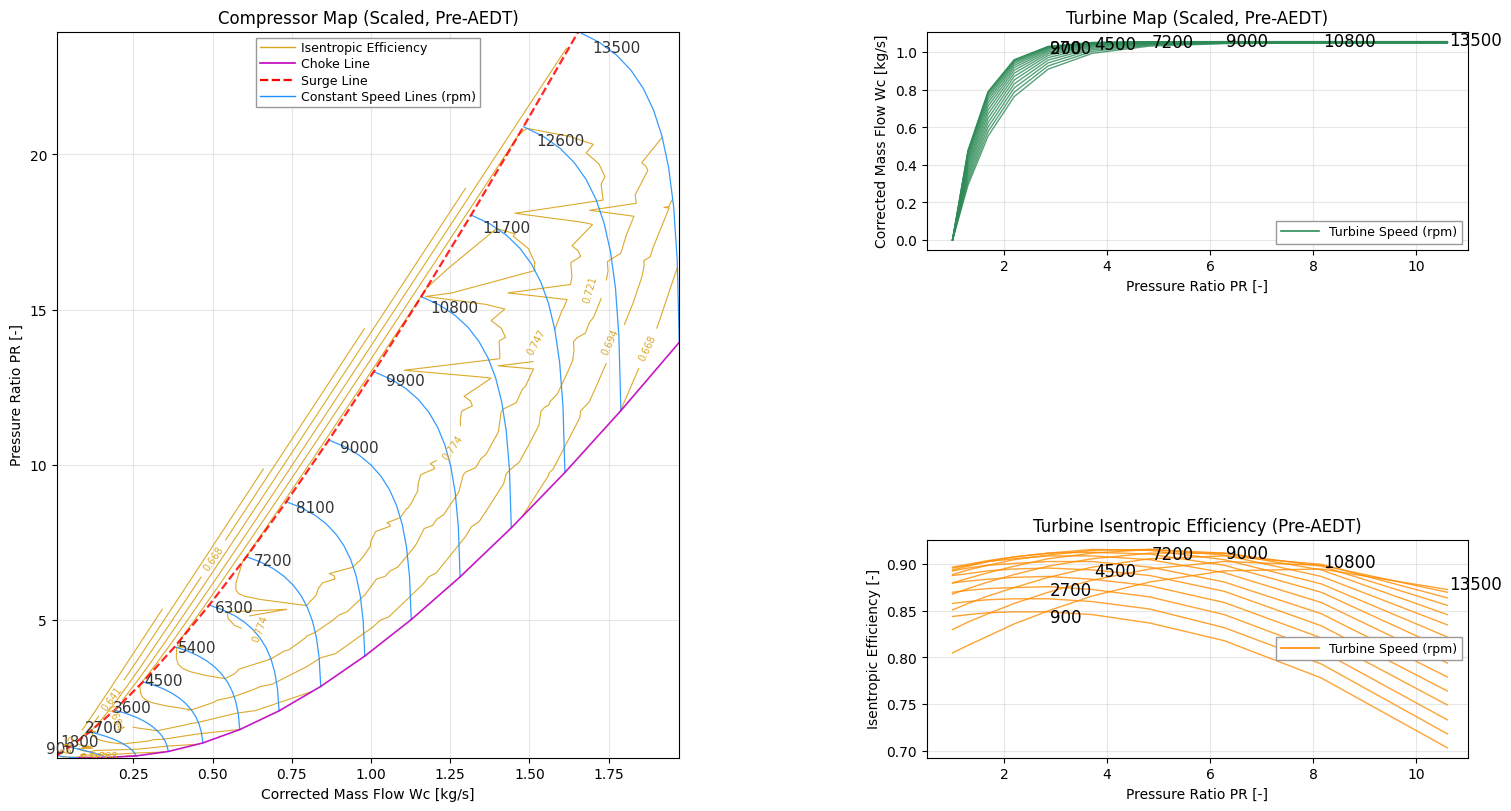

Pre-AEDT map preview: compressor constant speed lines + efficiency contours added; turbine style preserved.


In [28]:
# Compressor/Turbine map static plots (Pre-AEDT, MATLAB-style layout)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.tri import Triangulation

fig = plt.figure(figsize=(15, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1.15, 1.0], hspace=0.28, wspace=0.25)

# (a) Compressor map (left, spans two rows)
ax_cmp = fig.add_subplot(gs[:, 0])

# Compressor efficiency contour lines (no fill)
wc_flat = Wc_map_scaled.ravel()
pr_flat = PR_map_scaled.ravel()
eff_flat = eff_map_phys.ravel()
mask_cmp = np.isfinite(wc_flat) & np.isfinite(pr_flat) & np.isfinite(eff_flat) & (wc_flat > 0) & (pr_flat > 0)
if np.count_nonzero(mask_cmp) > 10:
    tri_cmp = Triangulation(wc_flat[mask_cmp], pr_flat[mask_cmp])
    eff_min = float(np.nanmin(eff_flat[mask_cmp]))
    eff_max = float(np.nanmax(eff_flat[mask_cmp]))
    if eff_max > eff_min:
        levels_cmp = np.linspace(eff_min, eff_max, 12)
        cset = ax_cmp.tricontour(
            tri_cmp,
            eff_flat[mask_cmp],
            levels=levels_cmp,
            colors='goldenrod',
            linewidths=0.8,
            alpha=0.95
        )
        ax_cmp.clabel(cset, inline=True, fontsize=7, fmt='%.3g')

# Constant speed lines with rpm labels
rpm_cmp = Nc_cmp * CMP_DES.get('NmechDes', 9000.0)
for i in range(len(Nc_cmp)):
    ax_cmp.plot(Wc_map_scaled[i, :], PR_map_scaled[i, :], color='dodgerblue', lw=0.9, alpha=0.9)
    label_idx = min(max(int(0.80 * (Wc_map_scaled.shape[1] - 1)), 1), Wc_map_scaled.shape[1] - 1)
    x_txt = Wc_map_scaled[i, label_idx]
    y_txt = PR_map_scaled[i, label_idx]
    ax_cmp.text(x_txt, y_txt, f"{int(round(rpm_cmp[i]))}", fontsize=11, color='0.2', ha='center', va='bottom')

ax_cmp.plot(Wc_map_scaled[:, -1], PR_map_scaled[:, -1], 'r--', lw=1.6, alpha=0.85)
ax_cmp.plot(Wc_map_scaled[:, 0], PR_map_scaled[:, 0], 'm-', lw=1.2, alpha=0.9)

cmp_legend_handles = [
    Line2D([0], [0], color='goldenrod', lw=1.0, label='Isentropic Efficiency'),
    Line2D([0], [0], color='m', lw=1.2, label='Choke Line'),
    Line2D([0], [0], color='r', lw=1.6, linestyle='--', label='Surge Line'),
    Line2D([0], [0], color='dodgerblue', lw=1.0, label='Constant Speed Lines (rpm)'),
]
ax_cmp.legend(
    handles=cmp_legend_handles,
    fontsize=9,
    loc='upper center',
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor='0.6',
    borderpad=0.3,
    handlelength=2.8,
    labelspacing=0.25,
    handletextpad=0.5
)
ax_cmp.set_title('Compressor Map (Scaled, Pre-AEDT)')
ax_cmp.set_xlabel('Corrected Mass Flow Wc [kg/s]')
ax_cmp.set_ylabel('Pressure Ratio PR [-]')
ax_cmp.grid(True, alpha=0.3)

# Turbine speed labels (rpm) converted from corrected speed Nc
rpm_trb = Nc_trb * TRB_DES.get('NmechDes', 9000.0)
n_label = min(7, len(Nc_trb))
label_line_idx = np.linspace(0, len(Nc_trb) - 1, n_label, dtype=int)
label_pr_idx = np.linspace(int(0.55 * (len(PR_trb_tbl_hdr) - 1)), len(PR_trb_tbl_hdr) - 1, n_label, dtype=int)

# (b) Turbine map (top-right): PR vs corrected mass flow
ax_trb_wc = fig.add_subplot(gs[0, 1])
for i in range(len(Nc_trb)):
    ax_trb_wc.plot(PR_trb_tbl_hdr, Wc_trb_map_scaled[i, :], color='seagreen', lw=1.0, alpha=0.8)

for k, i_line in enumerate(label_line_idx):
    j = int(label_pr_idx[k])
    x = PR_trb_tbl_hdr[j] + 0.03
    y = Wc_trb_map_scaled[i_line, j] + (k - (n_label - 1) / 2.0) * 0.004
    ax_trb_wc.text(x, y, f"{int(round(rpm_trb[i_line]))}", fontsize=12, color='black', ha='left', va='center')

ax_trb_wc.legend(
    handles=[Line2D([0], [0], color='seagreen', lw=1.2, label='Turbine Speed (rpm)')],
    loc='lower right',
    fontsize=9,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor='0.6',
    handlelength=3.0
)
ax_trb_wc.set_title('Turbine Map (Scaled, Pre-AEDT)')
ax_trb_wc.set_xlabel('Pressure Ratio PR [-]')
ax_trb_wc.set_ylabel('Corrected Mass Flow Wc [kg/s]')
ax_trb_wc.set_xlim(PR_trb_tbl_hdr[0] - 0.5, PR_trb_tbl_hdr[-1] + 0.4)
ax_trb_wc.grid(True, alpha=0.3)

# (c) Turbine efficiency map (bottom-right): PR vs isentropic efficiency
ax_trb_eff = fig.add_subplot(gs[1, 1])
for i in range(len(Nc_trb)):
    ax_trb_eff.plot(PR_trb_tbl_hdr, eff_trb_table[i, :], color='darkorange', lw=1.0, alpha=0.8)

for k, i_line in enumerate(label_line_idx):
    j = int(label_pr_idx[k])
    x = PR_trb_tbl_hdr[j] + 0.03
    y = eff_trb_table[i_line, j] + (k - (n_label - 1) / 2.0) * 0.0018
    ax_trb_eff.text(x, y, f"{int(round(rpm_trb[i_line]))}", fontsize=12, color='black', ha='left', va='center')

ax_trb_eff.legend(
    handles=[Line2D([0], [0], color='darkorange', lw=1.2, label='Turbine Speed (rpm)')],
    loc='center right',
    fontsize=9,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor='0.6',
    handlelength=3.0
)
ax_trb_eff.set_title('Turbine Isentropic Efficiency (Pre-AEDT)')
ax_trb_eff.set_xlabel('Pressure Ratio PR [-]')
ax_trb_eff.set_ylabel('Isentropic Efficiency [-]')
ax_trb_eff.set_xlim(PR_trb_tbl_hdr[0] - 0.5, PR_trb_tbl_hdr[-1] + 0.4)
ax_trb_eff.grid(True, alpha=0.3)

plt.show()
print('Pre-AEDT map preview: compressor constant speed lines + efficiency contours added; turbine style preserved.')

### Compressor/Turbine Map 기술 해설 (Modelica 데이터 기반)

본 플롯은 Modelica 모델에서 추출한 compressor/turbine 맵을 Python에서 동일 좌표계로 재구성한 결과이다.  
해석의 목적은 운전점 하나의 값 확인이 아니라, 압력비-유량-효율-안정여유가 동시에 만족되는 운전 가능 영역을 구조적으로 파악하는 데 있다.

#### 1) 보정 변수(corrected variable) 정의와 사용 이유
맵 비교는 입구 총온/총압 조건 변화에 민감하므로, 원시 변수($\dot m$, $N$) 대신 보정 변수를 사용한다.

$$
W_c = \dot m \frac{\sqrt{T_{t,in}/T_{ref}}}{P_{t,in}/P_{ref}}, \qquad
N_c = \frac{N}{\sqrt{T_{t,in}/T_{ref}}}
$$

이 정의를 사용하면 계절/고도/흡기 조건 변화가 있어도 성능 좌표를 동일 맵에서 일관되게 비교할 수 있다.

#### 2) Compressor map 해석 기준
압축기 압력비와 등엔트로픽 효율은 각각 다음으로 정의한다.

$$
\Pi_c = \frac{P_{t,out}}{P_{t,in}}, \qquad
\eta_c = \frac{T_{t,out,s}-T_{t,in}}{T_{t,out}-T_{t,in}}
$$

- speed line: 거의 일정한 $N_c$ 조건의 운전 궤적
- efficiency contour: 동일 $\eta_c$를 갖는 점들의 집합
- 안정성 관점: surge 경계(저유량 불안정)와 choke 측 경계(고유량 제한) 사이에서 운전 여유를 확보해야 함

#### 3) Turbine PR-$W_c$ 맵의 물리적 의미
터빈 압력비는

$$
\Pi_t = \frac{P_{t,in}}{P_{t,out}}
$$

로 두며, 각 speed line은 특정 $N_c$ 조건에서 가능한 $\Pi_t$-$W_c$ 조합을 나타낸다.

실무적으로는 $\Pi_t$ 증가가 가능한 엔탈피 강하를 키우고, 그 결과 축출력 잠재량과 유량 특성이 함께 이동한다.  
따라서 동일 압력비라도 속도선 위치에 따라 허용 유량과 효율 조건이 달라진다.

#### 4) Turbine PR-효율 맵 해석
터빈 등엔트로픽 효율은

$$
\eta_t = \frac{T_{t,in}-T_{t,out}}{T_{t,in}-T_{t,out,s}}
$$

로 정의한다. 고효율 대역은 일반적으로 중간 압력비 영역에 형성되며, 저PR/고PR 극단으로 갈수록 손실 증가로 효율이 저하된다.  
설계점 선정 시에는 최대 효율점 자체보다, 요구 부하 범위에서 효율 저하 기울기가 완만한 영역을 우선하는 것이 유리하다.

#### 5) 설계 검토 절차(권장)
1. 요구 축동력 및 회전수 범위를 정의한다.  
2. Compressor 맵에서 surge/choke margin을 만족하는 후보 운전대역을 선별한다.  
3. Turbine PR-$W_c$ 맵에서 후보 대역의 구동 가능성을 검증한다.  
4. Turbine 효율맵으로 연료소모 및 열부하 관점의 우선순위를 최종 조정한다.

요약하면 본 플롯은 단일 성능지표 확인용 그래프가 아니라, 사이클 매칭과 운전 여유를 동시에 검토하기 위한 맵 기반 설계 인터페이스로 해석하는 것이 적절하다.

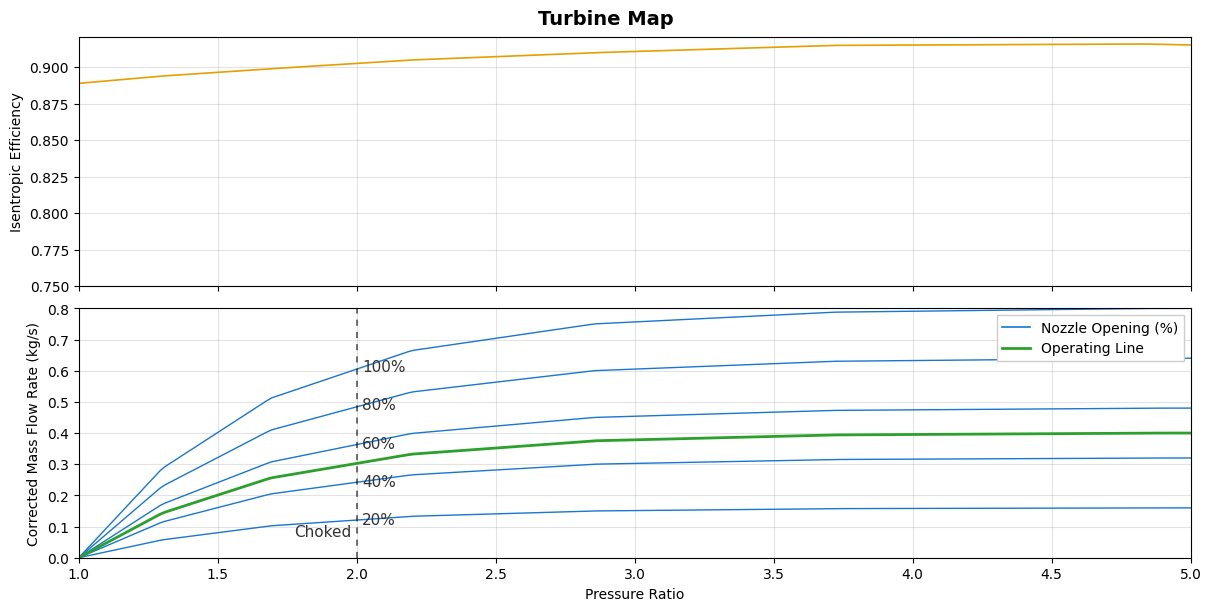

Nozzle-opening turbine map preview added (visualization model, Pre-AEDT).


In [29]:
# Additional turbine map by nozzle opening (Pre-AEDT visualization)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use design-speed turbine line as base and build nozzle-opening family for visualization.
nc_ref = TRB_DES.get('NcTblDes', 1.0)
i_ref = int(np.argmin(np.abs(Nc_trb - nc_ref)))

pr_min = max(1.0, float(np.min(PR_trb_tbl_hdr)))
pr_max = min(5.0, float(np.max(PR_trb_tbl_hdr)))
pr_plot = np.linspace(pr_min, pr_max, 220)

wc_base = np.interp(pr_plot, PR_trb_tbl_hdr, Wc_trb_map_scaled[i_ref, :])
eff_base = np.interp(pr_plot, PR_trb_tbl_hdr, eff_trb_table[i_ref, :])

# Normalize to a compact range to mimic control-map style view in the reference figure.
target_wc_max = 0.80
wc_scale = target_wc_max / max(float(np.max(wc_base)), 1e-9)
wc_base_vis = wc_base * wc_scale

openings = [20, 40, 60, 80, 100]
opening_curves = {}
for op in openings:
    opening_curves[op] = wc_base_vis * (op / 100.0)

# Example operating line (fixed-opening preview)
operating_opening = 50
wc_operating = wc_base_vis * (operating_opening / 100.0)

# Choke marker (visual cue)
pr_choke = 2.0

fig_noz, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
fig_noz.suptitle('Turbine Map', fontsize=14, fontweight='bold')

# Top: isentropic efficiency vs PR
ax_top.plot(pr_plot, eff_base, color='#e69f00', lw=1.2)
ax_top.set_ylabel('Isentropic Efficiency')
ax_top.set_ylim(0.75, max(0.85, float(np.max(eff_base)) + 0.005))
ax_top.grid(True, alpha=0.35)

# Bottom: corrected mass flow vs PR by nozzle opening
for op in openings:
    ax_bot.plot(pr_plot, opening_curves[op], color='#1976d2', lw=1.0)

ax_bot.plot(pr_plot, wc_operating, color='#2ca02c', lw=2.0, label='Operating Line')
ax_bot.axvline(pr_choke, color='k', lw=1.1, ls=(0, (4, 4)), alpha=0.7)
ax_bot.text(pr_choke - 0.02, 0.06, 'Choked', ha='right', va='bottom', fontsize=11, color='0.2')

# Opening labels near choke boundary
for op in openings:
    y_lbl = float(np.interp(pr_choke + 0.02, pr_plot, opening_curves[op]))
    ax_bot.text(pr_choke + 0.02, y_lbl, f'{op}%', fontsize=11, color='0.2', va='center')

legend_handles = [
    Line2D([0], [0], color='#1976d2', lw=1.2, label='Nozzle Opening (%)'),
    Line2D([0], [0], color='#2ca02c', lw=2.0, label='Operating Line'),
]
ax_bot.legend(handles=legend_handles, loc='upper right', fontsize=10, frameon=True, framealpha=1.0, fancybox=False)

ax_bot.set_xlabel('Pressure Ratio')
ax_bot.set_ylabel('Corrected Mass Flow Rate (kg/s)')
ax_bot.set_xlim(pr_min, pr_max)
ax_bot.set_ylim(0.0, target_wc_max)
ax_bot.grid(True, alpha=0.35)

plt.show()
print('Nozzle-opening turbine map preview added (visualization model, Pre-AEDT).')

## ── 1) Turbo.aedt 프로젝트 연결 ──────────────────────────────────────────

In [2]:
# 핵심: .aedt 확장자 포함 전체 경로 → 기존 열린 프로젝트에 attach
TURBO_PROJECT = r"E:\KDH\simTemp\TB\Turbo.aedt"
DESIGN_NAME = "TurboJet_ex01"
NG_MODE = False
AEDT_VERSION = "2026.1"

tb_mca = app.TwinBuilder(
    project=TURBO_PROJECT,
    design=DESIGN_NAME,
    non_graphical=NG_MODE,
    new_desktop=False,
    version=AEDT_VERSION,
)
print(f"Connected: {tb_mca.project_name} / {tb_mca.design_name}")
print(f"Project path: {tb_mca.project_path}")
print(f"Design list: {tb_mca.design_list}")


PyAEDT INFO: Parsing E:\KDH\simTemp\TB\Turbo.aedt.
PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 50051.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 50051.
PyAEDT INFO: File E:\KDH\simTemp\TB\Turbo.aedt correctly loaded. Elapsed time: 0m 5sec
PyAEDT INFO: Project Turbo set to active.
PyAEDT INFO: Active Design set to 4;TurboJet_ex01
PyAEDT INFO: AEDT objects correctly read
Connected: Turbo / TurboJet_ex01
Project path: E:/KDH/simTemp/TB/
Design list: ['CompTurbExp03_Design', 'TurboProp1', 'TurboJet_ex01']
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 3sec
  solutions: ['TR']
  categories: ['All']
  api ok: {'solution': 'TR', 'quantities_category': 'All', 'repor


## ── 2) API listing 시도 ────────────────────────────────────


In [ ]:
def _as_list(value):
    if value is None: return []
    if isinstance(value, (list, tuple, set)): return list(value)
    return [value]

def _read_attr_or_call(obj, name):
    if not hasattr(obj, name): return []
    v = getattr(obj, name)
    try: return _as_list(v()) if callable(v) else _as_list(v)
    except: return []

def _parse_exprs_from_post_api(tb_obj):
    post = tb_obj.post
    solutions = _read_attr_or_call(post, "available_report_solutions")
    categories = _read_attr_or_call(post, "available_quantities_categories")
    report_types = ["Standard", "Transient", None]
    print(f"  solutions: {solutions}")
    print(f"  categories: {categories if categories else '(none)'}")
    exprs = []
    fn = getattr(post, "available_report_quantities", None)
    if not callable(fn): return [], solutions
    for sol in (solutions or [None]):
        for cat in (categories or [None]):
            for rpt in report_types:
                kwargs = {}
                if sol is not None: kwargs["solution"] = sol
                if cat is not None: kwargs["quantities_category"] = cat
                if rpt is not None: kwargs["report_category"] = rpt
                try:
                    got = fn(**kwargs)
                    if got:
                        exprs.extend(list(got))
                        print(f"  api ok: {kwargs} -> {len(got)}")
                except: continue
    return sorted(set(exprs)), solutions

post_exprs, post_solutions = _parse_exprs_from_post_api(tb_mca)
setup_name = post_solutions[0] if post_solutions else "TR"
print(f"\nAPI listing 결과: {len(post_exprs)}개, setup_name='{setup_name}'")

## ── 3) 3619개 표현식에서 주요 물리량만 필터링 ─────────────────────────────


In [3]:
## Twin Builder Modelica 변수 네이밍:
#   TurboJetEx01_1.Cmp_pwr        ← Cmp.pwr
#   TurboJetEx01_1.inertia1_w     ← inertia1.w
#   TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_combiTable2D_PR_table_15_1_
#                                  ↑ 내부 보간 테이블 (불필요)
# 전략: (1) 내부 테이블/보간 변수 제외 → (2) 주요 물리량 패턴 매칭

import re

print(f"전체 표현식: {len(post_exprs)}개")

# ── 제외 패턴: combiTable 내부, table 인덱스, 보간 중간값 ──
EXCLUDE_PATTERNS = [
    r"combiTable",      # 룩업테이블 내부
    r"table_\d",        # 테이블 인덱스
    r"tableOnFile",     # 파일기반 테이블
    r"interpol",        # 보간 중간값
    r"_iderState",      # 상태 ID
    r"_tableID",
    r"smoothness",
    r"extrapolation",
    r"columns\[",
    r"fileName",
    r"verboseRead",
    r"tableName",
]
exclude_re = re.compile("|".join(EXCLUDE_PATTERNS), re.IGNORECASE)

# 1단계: 내부 변수 제거
filtered = [e for e in post_exprs if not exclude_re.search(e)]
print(f"제외 후: {len(filtered)}개 (테이블/보간 내부 {len(post_exprs)-len(filtered)}개 제거)")

# ── 주요 물리량 키워드 매칭 (PropulsionSystem 기준) ──
# 짧은 말단 변수명 기준으로 매칭 (밑줄 기준 마지막 토큰)
KEY_SUFFIXES = {
    # 동력/토크
    "pwr": "Power [W]",
    "trq": "Torque [N·m]",
    # 회전
    "w": "Angular velocity [rad/s]",
    "Nmech": "Mech speed [rpm]",
    "omega": "Omega [rad/s]",
    # 열역학 성능
    "PR": "Pressure Ratio [-]",
    "eff": "Efficiency [-]",
    "Wc_1": "Corrected flow [kg/s]",
    "Nc_1": "Corrected speed [rpm]",
    # 추력/성능
    "Fg": "Gross thrust [N]",
    "y_Fg": "Gross thrust (output) [N]",
    "Fn": "Net thrust [N]",
    "y_Fn": "Net thrust (output) [N]",
    "TSFC": "TSFC [kg/(N·s)]",
    "y_TSFC": "TSFC (output)",
    "y_FdRam": "Ram drag [N]",
    "V_2": "Nozzle exit velocity [m/s]",
    # 연료
    "y_m_flow_fuel": "Fuel flow [kg/s]",
    # 유동 상태
    "m_flow": "Mass flow [kg/s]",
    # 온도 (fluid_1_T, fluid_2_T 형태)
    "fluid_1_T": "Inlet temp [K]",
    "fluid_2_T": "Outlet temp [K]",
    # 압력
    "port_1_p": "Inlet pressure [Pa]",
    "port_2_p": "Outlet pressure [Pa]",
    # 연소기
    "effComb": "Combustion eff [-]",
}

# 2단계: 주요 물리량만 선별
def _match_key_signal(expr):
    """표현식이 주요 물리량에 해당하는지 판정."""
    # 디자인 접두어 제거 (e.g. "TurboJetEx01_1.")
    parts = expr.split(".", 1)
    varpath = parts[1] if len(parts) > 1 else parts[0]
    
    # 정확한 suffix 매칭 (밑줄 구분 마지막 토큰)
    tokens = varpath.split("_")
    
    # 끝에서부터 suffix 조합 시도
    for n in range(1, min(4, len(tokens)+1)):
        suffix = "_".join(tokens[-n:])
        if suffix in KEY_SUFFIXES:
            return suffix, KEY_SUFFIXES[suffix]
    
    # 특수 케이스: 단일 토큰 (e.g. "inertia1_w" → "w")
    last = tokens[-1] if tokens else ""
    if last in KEY_SUFFIXES:
        return last, KEY_SUFFIXES[last]
    
    return None, None

selected = {}
for expr in filtered:
    suffix, desc = _match_key_signal(expr)
    if suffix:
        # 같은 suffix가 여러 컴포넌트에 있을 수 있으므로 모두 수집
        if expr not in selected:
            selected[expr] = (suffix, desc)

# 컴포넌트별 그룹핑하여 출력
print(f"\n=== 선별된 주요 신호: {len(selected)}개 ===")
# 컴포넌트 추출 (접두어.컴포넌트_변수)
by_component = {}
for expr, (suffix, desc) in sorted(selected.items()):
    parts = expr.split(".", 1)
    varpath = parts[1] if len(parts) > 1 else parts[0]
    # 첫 번째 밑줄까지가 컴포넌트
    comp = varpath.split("_")[0] if "_" in varpath else varpath
    by_component.setdefault(comp, []).append((expr, suffix, desc))

for comp, signals in sorted(by_component.items()):
    print(f"\n  [{comp}]")
    for expr, suffix, desc in signals:
        print(f"    {suffix:18s} → {expr}")

# raw_exprs를 선별된 것으로 교체
raw_exprs = list(selected.keys())
print(f"\n→ 최종 수집 대상: {len(raw_exprs)}개 신호")

전체 표현식: 3619개
제외 후: 1623개 (테이블/보간 내부 1996개 제거)

=== 선별된 주요 신호: 138개 ===

  [Cmp]
    PR                 → TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_PR
    eff                → TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_eff
    Nc_1               → TurboJetEx01_1.Cmp_Nc_1
    Nmech              → TurboJetEx01_1.Cmp_Nmech
    PR                 → TurboJetEx01_1.Cmp_PR
    PR                 → TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR
    eff                → TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff
    PR                 → TurboJetEx01_1.Cmp_SclCmp_u_PR
    eff                → TurboJetEx01_1.Cmp_SclCmp_u_eff
    PR                 → TurboJetEx01_1.Cmp_SclCmp_u_s_PR
    eff                → TurboJetEx01_1.Cmp_SclCmp_u_s_eff
    Wc_1               → TurboJetEx01_1.Cmp_Wc_1
    eff                → TurboJetEx01_1.Cmp_eff
    Nmech              → TurboJetEx01_1.Cmp_flange_1_des_Nmech
    omega              → TurboJetEx01_1.Cmp_flange_1_des_om

## ── 4) 시계열 수집 (collect_time_domain_results 패턴) ──────────────


In [4]:

def _get_signal(tb_obj, expr, setup_name=None):
    """pyAEDT post에서 단일 표현식의 시계열 (t, y) 추출."""
    post = getattr(tb_obj, "post", None)
    if post is None: return None, None
    attempts = [
        {"expressions": [expr], "domain": "Time", "setup_sweep_name": setup_name},
        {"expressions": [expr], "domain": "Time"},
    ]
    for kwargs in attempts:
        try:
            sol_data = post.get_solution_data(**kwargs)
            if sol_data is None: continue
            t = np.asarray(sol_data.primary_sweep_values, dtype=float)
            y = np.asarray(sol_data.data_real(expr), dtype=float)
            if len(t) > 0 and len(y) > 0:
                return t, y
        except:
            continue
    return None, None

if not raw_exprs:
    raise RuntimeError("유효한 표현식 없음 — Cell 95에서 필터링 결과 확인")

print(f"수집 대상: {len(raw_exprs)}개 신호")
# 전체 신호 수집
SIGNAL_MAP = {e: e for e in raw_exprs}

merged = None
found_sigs = []
missing_sigs = []

for alias, expr in SIGNAL_MAP.items():
    t, y = _get_signal(tb_mca, expr, setup_name=setup_name)
    if t is None:
        missing_sigs.append(expr)
        continue
    found_sigs.append(expr)
    df_sig = pd.DataFrame({"time": t, alias: y}).dropna()
    if merged is None:
        merged = df_sig
    else:
        merged = merged.merge(df_sig, on="time", how="outer")

if merged is not None:
    merged = merged.sort_values("time").drop_duplicates(subset=["time"]).reset_index(drop=True)
    # 시간 스케일 보정 (ps→s)
    t_arr = merged["time"].to_numpy(dtype=float)
    t_span = float(np.nanmax(t_arr) - np.nanmin(t_arr))
    if t_span > 1e6:
        merged["time"] = merged["time"] * 1e-12
        print(f"시간축: ps → s 변환 (span={t_span:.2e})")
    print(f"\n수집 완료: {len(merged)} steps, {len(found_sigs)} signals")
    print(f"시간: {merged['time'].iloc[0]:.3f} ~ {merged['time'].iloc[-1]:.3f} s")
    display(merged.describe())
else:
    print("시계열 데이터 없음!")

mdf = merged

수집 대상: 138개 신호
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


...

PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
시간축: ps → s 변환 (span=4.00e+11)

수집 완료: 410 steps, 138 signals
시간: 0.000 ~ 0.400 s


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


,time,TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_PR,TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_eff,TurboJetEx01_1.Cmp_Nc_1,TurboJetEx01_1.Cmp_Nmech,TurboJetEx01_1.Cmp_PR,TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR,TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff,TurboJetEx01_1.Cmp_SclCmp_u_PR,TurboJetEx01_1.Cmp_SclCmp_u_eff,...,TurboJetEx01_1.Trb_variablesDes_Wc_1,TurboJetEx01_1.Trb_variablesDes_eff,TurboJetEx01_1.Trb_variablesDes_omega,TurboJetEx01_1.Trb_variablesDes_pwr,TurboJetEx01_1.Trb_variablesDes_trq,TurboJetEx01_1.boundary_m_flow,TurboJetEx01_1.boundary_ports_1__m_flow,TurboJetEx01_1.inertia1_w,TurboJetEx01_1.system_eps_m_flow,TurboJetEx01_1.temperature_port_m_flow
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,4.100000e+02,410.000000,410.000000,410.000000,...,410.000000,410.0,410.000000,410.000000,410.000000,410.0,410.000000,410.000000,4.100000e+02,410.0
mean,0.196064,25.249902,0.824207,9269.717260,8665.892860,11.407407,2.197056e+01,0.931789,25.249902,0.824207,...,0.296627,0.8,907.490178,-157825.524589,-173.740789,0.0,-0.030581,907.490178,1.000000e-04,0.0
std,0.118065,1.573342,0.001986,299.436453,279.931324,0.675236,7.114108e-15,0.000000,1.573342,0.001986,...,0.000893,0.0,29.314340,9880.713000,6.333199,0.0,0.001983,29.314340,1.356908e-20,0.0
min,0.000000,19.701428,0.819027,8245.459634,7708.354825,9.026151,2.197056e+01,0.931789,19.701428,0.819027,...,0.296261,0.8,807.217030,-161501.515319,-175.562793,0.0,-0.031000,807.217030,1.000000e-04,0.0
25%,0.093550,25.698201,0.824063,9355.777396,8746.347084,11.599805,2.197056e+01,0.931789,25.698201,0.824063,...,0.296261,0.8,915.915325,-161501.319301,-175.562739,0.0,-0.031000,915.915325,1.000000e-04,0.0
50%,0.195800,25.910765,0.824097,9395.961129,8783.913271,11.691032,2.197056e+01,0.931789,25.910765,0.824097,...,0.296263,0.8,919.849247,-161487.830073,-175.559018,0.0,-0.031000,919.849247,1.000000e-04,0.0
75%,0.298050,25.913869,0.824097,9396.546812,8784.460803,11.692364,2.197056e+01,0.931789,25.913869,0.824097,...,0.296387,0.8,919.906584,-160563.176598,-175.303515,0.0,-0.031000,919.906584,1.000000e-04,0.0
max,0.400000,25.913914,0.833077,9396.555323,8784.468759,11.692384,2.197056e+01,0.931789,25.913914,0.833077,...,0.300169,0.8,919.907417,-116154.351978,-143.894823,0.0,-0.021000,919.907417,1.000000e-04,0.0


## ── 5) Modelica 엔진 과도응답 분석 플롯 ──────────

mdf columns (138): ['TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_PR', 'TurboJetEx01_1.Cmp_CmpTbl_WcPReff_NcRline_y_eff', 'TurboJetEx01_1.Cmp_Nc_1', 'TurboJetEx01_1.Cmp_Nmech', 'TurboJetEx01_1.Cmp_PR', 'TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR', 'TurboJetEx01_1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff', 'TurboJetEx01_1.Cmp_SclCmp_u_PR']...

=== 동적 매칭 결과 ===
  ✓ omega        → TurboJetEx01_1.inertia1_w
  ✓ Nmech        → TurboJetEx01_1.Cmp_Nmech
  ✓ P_cmp        → TurboJetEx01_1.Cmp_pwr
  ✓ P_trb        → TurboJetEx01_1.Trb_pwr
  ✓ PR_cmp       → TurboJetEx01_1.Cmp_PR
  ✓ PR_trb       → TurboJetEx01_1.Trb_PR
  ✓ eff_cmp      → TurboJetEx01_1.Cmp_eff
  ✓ eff_trb      → TurboJetEx01_1.Trb_eff
  ✓ Fg           → TurboJetEx01_1.Nzl_y_Fg
  ✓ Fn           → TurboJetEx01_1.Perf_Fn
  ✓ FdRam        → TurboJetEx01_1.Inlt_y_FdRam
  ✓ T_cmp_out    → TurboJetEx01_1.Cmp_fluid_2_T
  ✓ TIT          → TurboJetEx01_1.Trb_fluid_1_T
  ✓ T_trb_out    → TurboJetEx01_1.Trb_flui

C:\Users\user\AppData\Local\Temp\ipykernel_29972\2403271594.py:105: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title("(f) Fuel & TSFC"); ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
C:\Users\user\AppData\Local\Temp\ipykernel_29972\2403271594.py:139: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29972\2403271594.py:139: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29972\2403271594.py:139: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29972\2403271594.py:139: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(

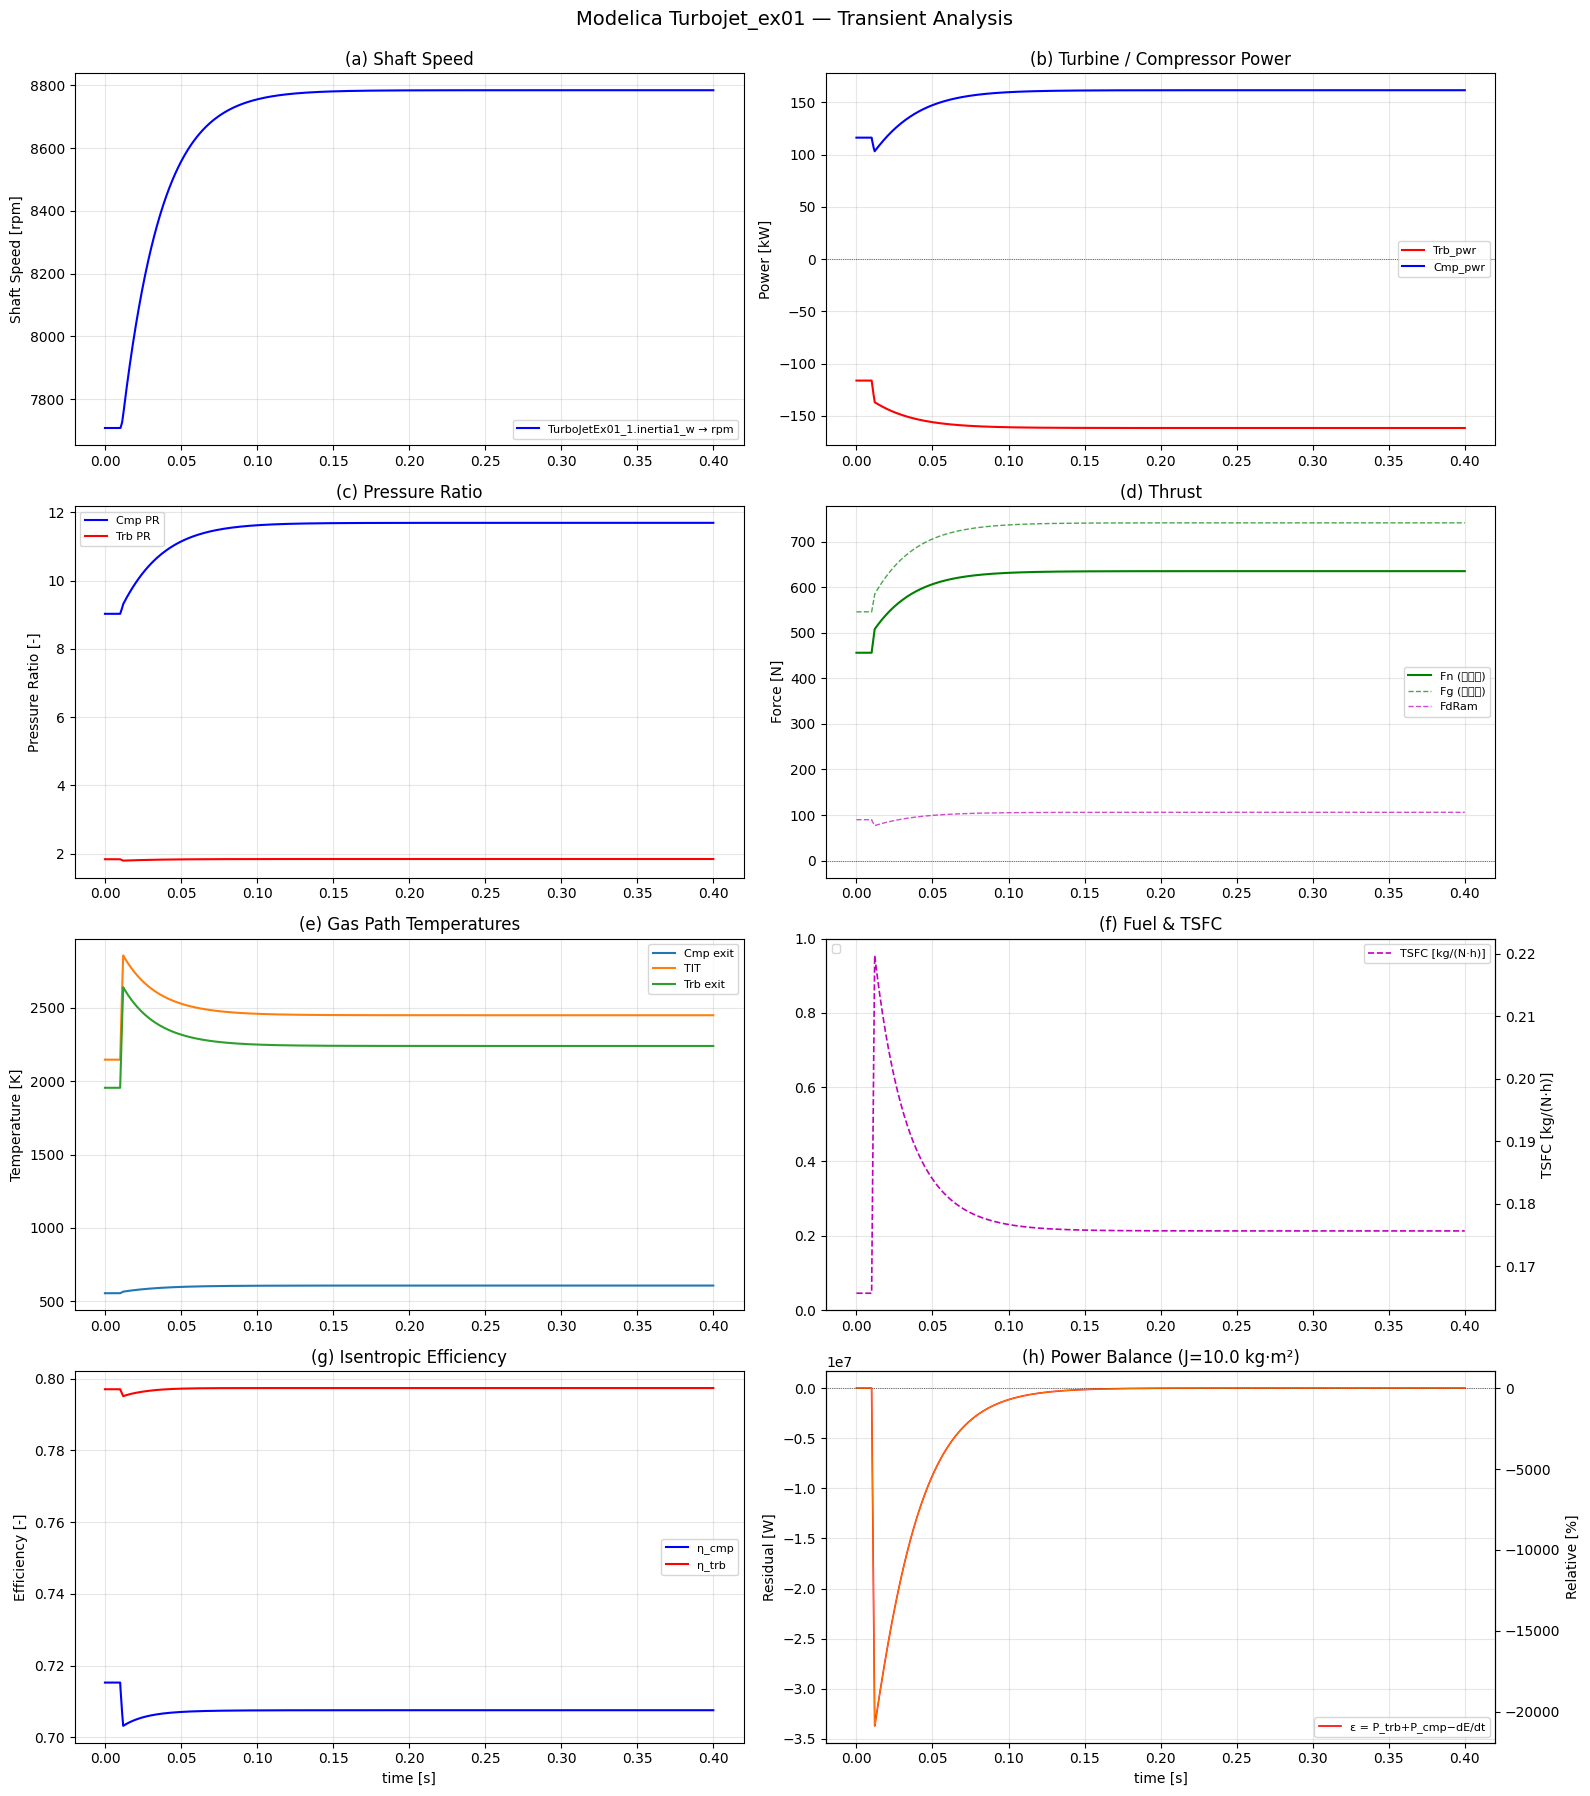

In [9]:
# Twin Builder 변수 포맷: TurboJetEx01_1.Cmp_pwr (Modelica Cmp.pwr → _ 로 평탄화)
# → 패턴 매칭 시 . 과 _ 를 동일 취급
J_SHAFT = 10.0  # inertia1.J in Turbojet_ex01
t = mdf["time"].to_numpy()
cols = [c for c in mdf.columns if c != "time"]

print(f"mdf columns ({len(cols)}): {cols[:8]}...")

def _find_col(patterns):
    """mdf 컬럼 중 patterns와 매칭 (. 과 _ 동일 취급)."""
    for p in patterns:
        p_norm = p.lower().replace(".", "_")
        for c in cols:
            c_norm = c.lower().replace(".", "_")
            if p_norm in c_norm:
                return c
    return None

# 주요 신호 동적 매칭 (Modelica 경로 + TB 평탄화 둘 다 커버)
col_omega   = _find_col(["inertia1_w", "inertia1.w"])
col_Nmech   = _find_col(["Cmp_Nmech", "Cmp.Nmech"])
col_P_cmp   = _find_col(["Cmp_pwr", "Cmp.pwr"])
col_P_trb   = _find_col(["Trb_pwr", "Trb.pwr"])
col_PR_cmp  = _find_col(["Cmp_PR"])
col_PR_trb  = _find_col(["Trb_PR"])
col_eff_cmp = _find_col(["Cmp_eff"])
col_eff_trb = _find_col(["Trb_eff"])
col_Fg      = _find_col(["Nzl_y_Fg", "Nzl_Fg", "Nzl.y_Fg"])
col_Fn      = _find_col(["Perf_Fn", "Perf_y_Fn", "Perf.Fn"])
col_FdRam   = _find_col(["Inlt_y_FdRam", "Inlt.y_FdRam", "Inlt_FdRam"])
col_T_cmp_out = _find_col(["Cmp_fluid_2_T", "Cmp.fluid_2.T"])
col_T_trb_in  = _find_col(["Trb_fluid_1_T", "Trb.fluid_1.T"])
col_T_trb_out = _find_col(["Trb_fluid_2_T", "Trb.fluid_2.T"])
col_TSFC    = _find_col(["Perf_TSFC", "Perf_y_TSFC", "Perf.TSFC"])
col_fuel    = _find_col(["Comb_y_m_flow_fuel", "Comb.y_m_flow_fuel", "m_flow_fuel"])
col_trq_cmp = _find_col(["Cmp_trq"])
col_trq_trb = _find_col(["Trb_trq"])

print("\n=== 동적 매칭 결과 ===")
for name, col in [("omega", col_omega), ("Nmech", col_Nmech),
                   ("P_cmp", col_P_cmp), ("P_trb", col_P_trb),
                   ("PR_cmp", col_PR_cmp), ("PR_trb", col_PR_trb),
                   ("eff_cmp", col_eff_cmp), ("eff_trb", col_eff_trb),
                   ("Fg", col_Fg), ("Fn", col_Fn), ("FdRam", col_FdRam),
                   ("T_cmp_out", col_T_cmp_out), ("TIT", col_T_trb_in),
                   ("T_trb_out", col_T_trb_out),
                   ("TSFC", col_TSFC), ("fuel", col_fuel)]:
    status = "✓" if col else "✗"
    print(f"  {status} {name:12s} → {col}")

# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle("Modelica Turbojet_ex01 — Transient Analysis", fontsize=14, y=0.995)

# ── (a) 샤프트 속도 ──
ax = axes[0, 0]
if col_omega:
    omega_arr = mdf[col_omega].to_numpy(dtype=float)
    ax.plot(t, omega_arr * 60/(2*np.pi), "b-", lw=1.5, label=f"{col_omega} → rpm")
elif col_Nmech:
    ax.plot(t, mdf[col_Nmech], "b-", lw=1.5, label=f"{col_Nmech} [rpm]")
ax.set_ylabel("Shaft Speed [rpm]"); ax.set_title("(a) Shaft Speed")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (b) 파워 ──
ax = axes[0, 1]
if col_P_trb: ax.plot(t, mdf[col_P_trb]/1e3, "r-", lw=1.5, label="Trb_pwr")
if col_P_cmp: ax.plot(t, mdf[col_P_cmp]/1e3, "b-", lw=1.5, label="Cmp_pwr")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_ylabel("Power [kW]"); ax.set_title("(b) Turbine / Compressor Power")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (c) 압력비 ──
ax = axes[1, 0]
if col_PR_cmp: ax.plot(t, mdf[col_PR_cmp], "b-", lw=1.5, label="Cmp PR")
if col_PR_trb: ax.plot(t, mdf[col_PR_trb], "r-", lw=1.5, label="Trb PR")
ax.set_ylabel("Pressure Ratio [-]"); ax.set_title("(c) Pressure Ratio")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (d) 추력 ──
ax = axes[1, 1]
if col_Fn: ax.plot(t, mdf[col_Fn], "g-", lw=1.5, label="Fn (순추력)")
if col_Fg: ax.plot(t, mdf[col_Fg], "g--", lw=1, alpha=0.7, label="Fg (총추력)")
if col_FdRam: ax.plot(t, mdf[col_FdRam], "m--", lw=1, alpha=0.7, label="FdRam")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_ylabel("Force [N]"); ax.set_title("(d) Thrust")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (e) 온도 ──
ax = axes[2, 0]
for col, label in [(col_T_cmp_out, "Cmp exit"), (col_T_trb_in, "TIT"), (col_T_trb_out, "Trb exit")]:
    if col: ax.plot(t, mdf[col], lw=1.5, label=label)
ax.set_ylabel("Temperature [K]"); ax.set_title("(e) Gas Path Temperatures")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (f) TSFC & 연료 ──
ax = axes[2, 1]
if col_fuel:
    ax.plot(t, mdf[col_fuel], "k-", lw=1.5, label="ṁ_fuel [kg/s]")
    ax.set_ylabel("Fuel Flow [kg/s]")
if col_TSFC:
    ax2f = ax.twinx()
    ax2f.plot(t, mdf[col_TSFC].to_numpy(dtype=float)*3600, "m--", lw=1.2, label="TSFC [kg/(N·h)]")
    ax2f.set_ylabel("TSFC [kg/(N·h)]"); ax2f.legend(loc="upper right", fontsize=8)
ax.set_title("(f) Fuel & TSFC"); ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)

# ── (g) 효율 ──
ax = axes[3, 0]
if col_eff_cmp: ax.plot(t, mdf[col_eff_cmp], "b-", lw=1.5, label="η_cmp")
if col_eff_trb: ax.plot(t, mdf[col_eff_trb], "r-", lw=1.5, label="η_trb")
ax.set_ylabel("Efficiency [-]"); ax.set_title("(g) Isentropic Efficiency")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (h) 파워 밸런스 ──
ax = axes[3, 1]
omega_src = col_omega or col_Nmech
if col_P_trb and col_P_cmp and omega_src:
    omega_arr = mdf[omega_src].to_numpy(dtype=float)
    if omega_src == col_Nmech:
        omega_arr = omega_arr * 2*np.pi/60  # rpm→rad/s
    E_kin = 0.5 * J_SHAFT * omega_arr**2
    dEdt = np.gradient(E_kin, t, edge_order=1)
    P_t = mdf[col_P_trb].to_numpy(dtype=float)
    P_c = mdf[col_P_cmp].to_numpy(dtype=float)
    eps_shaft = P_t + P_c - dEdt
    ax.plot(t, eps_shaft, "r-", lw=1.2, label="ε = P_trb+P_cmp−dE/dt")
    ax.axhline(0, color="k", lw=0.5, ls=":")
    P_scale = max(np.nanmax(np.abs(P_t)), 1.0)
    ax2h = ax.twinx()
    ax2h.plot(t, eps_shaft/P_scale*100, "orange", lw=0.8, alpha=0.7)
    ax2h.set_ylabel("Relative [%]")
    ax.set_ylabel("Residual [W]"); ax.set_title(f"(h) Power Balance (J={J_SHAFT} kg·m²)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
else:
    missing = [n for n, v in [("P_trb", col_P_trb), ("P_cmp", col_P_cmp), ("ω", omega_src)] if not v]
    ax.text(0.5, 0.5, f"미발견: {', '.join(missing)}", transform=ax.transAxes, ha="center", fontsize=11)

for a in axes[-1, :]: a.set_xlabel("time [s]")
plt.tight_layout()
plt.show()

## ── 6) 정량 검증 요약 & 에너지 보존 ──────────────────


In [6]:
print("=" * 70)
print("  Modelica Turbojet_ex01 — 과도 시뮬레이션 결과 요약")
print("=" * 70)

n_ss = max(1, len(t) // 10)

def _ss_val(col):
    if col and col in mdf.columns:
        arr = mdf[col].to_numpy(dtype=float)[-n_ss:]
        return float(np.nanmean(arr)), float(arr[-1])
    return None, None

print(f"\n  시뮬레이션: {t[0]:.2f} ~ {t[-1]:.2f} s ({len(t)} steps)")
print(f"  정상상태 구간: 마지막 {n_ss} steps")
print(f"  J_shaft = {J_SHAFT} kg·m²")

print("\n  ─── 정상상태 성능 (SS mean / final) ───")
items = [
    ("Shaft rpm", col_omega, lambda x: x*60/(2*np.pi) if col_omega and "nmech" not in col_omega.lower() else x, "rpm"),
    ("Cmp Power", col_P_cmp, lambda x: x/1e3, "kW"),
    ("Trb Power", col_P_trb, lambda x: x/1e3, "kW"),
    ("Cmp PR", col_PR_cmp, lambda x: x, "-"),
    ("Trb PR", col_PR_trb, lambda x: x, "-"),
    ("Cmp η", col_eff_cmp, lambda x: x, "-"),
    ("Trb η", col_eff_trb, lambda x: x, "-"),
    ("Fn", col_Fn, lambda x: x, "N"),
    ("Fg", col_Fg, lambda x: x, "N"),
    ("TSFC", col_TSFC, lambda x: x*3600, "kg/(N·h)"),
    ("Fuel", col_fuel, lambda x: x, "kg/s"),
    ("TIT", col_T_trb_in, lambda x: x, "K"),
]
for label, col, conv, unit in items:
    mean_v, last_v = _ss_val(col)
    if mean_v is not None:
        print(f"    {label:12s}: {conv(mean_v):12.4f} / {conv(last_v):12.4f} {unit}")

# 파워 밸런스
print("\n  ─── 파워 밸런스 ───")
if col_P_trb and col_P_cmp and col_omega:
    omega_arr = mdf[col_omega].to_numpy(dtype=float)
    if "nmech" in col_omega.lower():
        omega_arr = omega_arr * 2*np.pi/60
    E_kin = 0.5 * J_SHAFT * omega_arr**2
    dEdt = np.gradient(E_kin, t, edge_order=1)
    P_t = mdf[col_P_trb].to_numpy(dtype=float)
    P_c = mdf[col_P_cmp].to_numpy(dtype=float)
    eps = P_t + P_c - dEdt
    P_scale = max(np.nanmax(np.abs(P_t)), 1.0)

    print(f"    |P_trb| max:  {np.nanmax(np.abs(P_t)):.2e} W")
    print(f"    |P_cmp| max:  {np.nanmax(np.abs(P_c)):.2e} W")
    print(f"    |dE/dt| max:  {np.nanmax(np.abs(dEdt)):.2e} W")
    eps_rel = np.nanmean(np.abs(eps))/P_scale*100
    print(f"    |ε| mean:     {np.nanmean(np.abs(eps)):.2e} W ({eps_rel:.3f}%)")
    print(f"    |ε| max:      {np.nanmax(np.abs(eps)):.2e} W")

    eps_ss = eps[-n_ss:]
    eps_ss_pct = np.nanmean(np.abs(eps_ss))/P_scale*100
    print(f"    [SS] |ε| mean: {np.nanmean(np.abs(eps_ss)):.2e} W ({eps_ss_pct:.4f}%)")

    if eps_ss_pct < 1.0:
        print("\n    ✓ SS 파워 밸런스 양호")
    elif eps_ss_pct < 5.0:
        print(f"\n    △ SS 파워 밸런스 근사 ({eps_ss_pct:.2f}%)")
    else:
        print(f"\n    ✗ 파워 밸런스 불성립 ({eps_ss_pct:.1f}%)")
else:
    print("    필수 신호 미수집")

# 추력 일관성
if col_Fn and col_Fg and col_FdRam:
    Fn_ = mdf[col_Fn].to_numpy(dtype=float)
    Fg_ = mdf[col_Fg].to_numpy(dtype=float)
    Ram_ = mdf[col_FdRam].to_numpy(dtype=float)
    eps_th = Fn_ - (Fg_ - Ram_)
    print(f"\n  ─── 추력 일관성: Fn vs (Fg - FdRam) ───")
    print(f"    |ε| max: {np.nanmax(np.abs(eps_th)):.2e} N")

print("\n" + "=" * 70)

  Modelica Turbojet_ex01 — 과도 시뮬레이션 결과 요약

  시뮬레이션: 0.00 ~ 0.40 s (410 steps)
  정상상태 구간: 마지막 41 steps
  J_shaft = 10.0 kg·m²

  ─── 정상상태 성능 (SS mean / final) ───
    Shaft rpm   :    8784.4686 /    8784.4688 rpm
    Cmp Power   :     161.5015 /     161.5015 kW
    Trb Power   :    -161.5015 /    -161.5015 kW
    Cmp PR      :      11.6924 /      11.6924 -
    Trb PR      :       1.8399 /       1.8399 -
    Cmp η       :       0.7075 /       0.7075 -
    Trb η       :       0.7974 /       0.7974 -
    Fn          :     635.2914 /     635.2914 N
    Fg          :     741.3290 /     741.3290 N
    TSFC        :       0.1757 /       0.1757 kg/(N·h)
    TIT         :    2450.2862 /    2450.2861 K

  ─── 파워 밸런스 ───
    |P_trb| max:  1.62e+05 W
    |P_cmp| max:  1.62e+05 W
    |dE/dt| max:  3.37e+07 W
    |ε| mean:     2.63e+06 W (1625.903%)
    |ε| max:      3.37e+07 W
    [SS] |ε| mean: 1.21e+01 W (0.0075%)

    ✓ SS 파워 밸런스 양호

  ─── 추력 일관성: Fn vs (Fg - FdRam) ───
    |ε| max: 0.00e+00 N



## ── 7) 효율맵 운전궤적 + Brayton T-S / P-v 사이클 애니메이션


In [ ]:

# MathWorks BraytonCycleGasTurbine Example 스타일 재현
# - Compressor: x=Corrected Mass Flow, y=PR, Operating Line
# - Turbine: x=PR, y=Corrected Mass Flow (Plot3Turbine.m 스타일)
# - T-S: 등압선 배경 + 5-point cycle animation (Plot1TS.m 스타일)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.colors as mcolors

# ─── 기본 상수 (해면 정적 조건) ───
T_AMB = 288.15   # K
P_AMB = 101325.0 # Pa
cp_air = 1005.0  # J/(kg·K)
gamma = 1.4
R_air = 287.05   # J/(kg·K)

# ─── mdf 에서 시계열 추출 ───
plt.rcParams['animation.embed_limit'] = 60  # MB
t_anim = mdf["time"].to_numpy(dtype=float)
N_frames_total = len(t_anim)
STEP = max(1, N_frames_total // 120)
frame_idx = np.arange(0, N_frames_total, STEP)
N_frames = len(frame_idx)

# 운전점 데이터
omega_rpm = mdf[col_Nmech].to_numpy(dtype=float) if col_Nmech else (
    mdf[col_omega].to_numpy(dtype=float) * 60 / (2*np.pi))
PR_cmp_arr = mdf[col_PR_cmp].to_numpy(dtype=float)
PR_trb_arr = mdf[col_PR_trb].to_numpy(dtype=float)
eff_cmp_arr = mdf[col_eff_cmp].to_numpy(dtype=float)
eff_trb_arr = mdf[col_eff_trb].to_numpy(dtype=float)

# ─── Corrected Mass Flow Rate 계산 ───
# Compressor: Wc = m_dot * sqrt(T_in/T_ref) / (P_in/P_ref)
# mdf에서 Wc 컬럼 검색
col_Wc_cmp = None
col_Wc_trb = None
for c in mdf.columns:
    cl = c.lower()
    if col_Wc_cmp is None and 'cmp' in cl and 'wc_1' in cl and 'des' not in cl:
        col_Wc_cmp = c
    if col_Wc_trb is None and 'trb' in cl and 'wc_1' in cl and 'des' not in cl:
        col_Wc_trb = c

# Fallback: 더 넓은 검색
if col_Wc_cmp is None:
    for c in mdf.columns:
        if 'Cmp' in c and 'Wc' in c and 'Des' not in c and 'Scl' not in c and 'Tbl' not in c:
            col_Wc_cmp = c
            break
if col_Wc_trb is None:
    for c in mdf.columns:
        if 'Trb' in c and 'Wc' in c and 'Des' not in c and 'Scl' not in c and 'Tbl' not in c:
            col_Wc_trb = c
            break

# 최종 fallback: variablesDes_Wc_1 포함
if col_Wc_cmp is None:
    for c in mdf.columns:
        if 'Cmp' in c and 'Wc' in c:
            col_Wc_cmp = c
            break
if col_Wc_trb is None:
    for c in mdf.columns:
        if 'Trb' in c and 'Wc' in c:
            col_Wc_trb = c
            break

print(f"Corrected Mass Flow columns:")
print(f"  Compressor Wc: {col_Wc_cmp}")
print(f"  Turbine Wc:    {col_Wc_trb}")

# 배열 추출
if col_Wc_cmp:
    Wc_cmp_arr = mdf[col_Wc_cmp].to_numpy(dtype=float)
else:
    Wc_cmp_arr = omega_rpm / omega_rpm.max()
    print("  ⚠ Compressor Wc not found, using normalized Nmech as proxy")

if col_Wc_trb:
    Wc_trb_arr = mdf[col_Wc_trb].to_numpy(dtype=float)
else:
    Wc_trb_arr = omega_rpm / omega_rpm.max()
    print("  ⚠ Turbine Wc not found, using normalized Nmech as proxy")

# 스테이션 온도 (T-S, P-v 용)
T2_arr = mdf[col_T_cmp_out].to_numpy(dtype=float)
T3_arr = mdf[col_T_trb_in].to_numpy(dtype=float)
T4_arr = mdf[col_T_trb_out].to_numpy(dtype=float)

# 스테이션 압력
P1 = P_AMB
P2_arr = P1 * PR_cmp_arr
P3_arr = P2_arr
P4_arr = P3_arr / PR_trb_arr

# 엔트로피 변화 (기준: Station 1, s1=0)
T1 = T_AMB
s1 = 0.0
s2_arr = cp_air * np.log(T2_arr / T1) - R_air * np.log(P2_arr / P1)
s3_arr = cp_air * np.log(T3_arr / T1) - R_air * np.log(P3_arr / P1)
s4_arr = cp_air * np.log(T4_arr / T1) - R_air * np.log(P4_arr / P1)

# 비체적
v1 = R_air * T1 / P1
v2_arr = R_air * T2_arr / P2_arr
v3_arr = R_air * T3_arr / P3_arr
v4_arr = R_air * T4_arr / P4_arr

print(f"\nAnimation: {N_frames} frames (step={STEP}), t=[{t_anim[0]:.4f}, {t_anim[-1]:.4f}] s")
print(f"  Nmech range: {omega_rpm.min():.0f} ~ {omega_rpm.max():.0f} rpm")
print(f"  PR_cmp range: {PR_cmp_arr.min():.2f} ~ {PR_cmp_arr.max():.2f}")
print(f"  Wc_cmp range: {Wc_cmp_arr.min():.4f} ~ {Wc_cmp_arr.max():.4f}")
print(f"  PR_trb range: {PR_trb_arr.min():.2f} ~ {PR_trb_arr.max():.2f}")
print(f"  Wc_trb range: {Wc_trb_arr.min():.4f} ~ {Wc_trb_arr.max():.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# MathWorks Color Scheme
C_BLUE   = '#0072BD'
C_ORANGE = '#D95319'
C_YELLOW = '#EDB120'
C_PURPLE = '#7E2F8E'
C_GREEN  = '#77AC30'
C_CYAN   = '#4DBEEE'
C_RED    = '#A2142F'

# ═══════════════════════════════════════════════════════════════════════════
# Figure 설정 (3x2 layout) — MathWorks Turbine(G) 스타일 (Wc vs PR + eff vs PR)
import matplotlib.gridspec as gridspec
fig_anim = plt.figure(figsize=(15, 16))
gs = gridspec.GridSpec(3, 2, figure=fig_anim, height_ratios=[1, 1, 0.8], hspace=0.32, wspace=0.28)
fig_anim.suptitle("Turbojet_ex01 — Brayton Cycle Animation (MathWorks Style)", fontsize=13, y=0.995)

ax_cmp = fig_anim.add_subplot(gs[0, 0])
ax_trb = fig_anim.add_subplot(gs[0, 1])
ax_ts  = fig_anim.add_subplot(gs[1, 0])
ax_eff_trb = fig_anim.add_subplot(gs[1, 1])  # Turbine η vs PR (new)
ax_pv  = fig_anim.add_subplot(gs[2, 0])
ax_extra = fig_anim.add_subplot(gs[2, 1])
ax_extra.axis('off')  # placeholder

# ══════════════════════════════════════════════════════════════════════════
# (a) Compressor Map — BraytonCycleGasTurbinePlot2Compressor.m 스타일
#     x = Corrected Mass Flow Rate, y = Pressure Ratio
ax_cmp.set_facecolor("white")
ax_cmp.grid(True, alpha=0.3, linestyle='-', color='gray')
ax_cmp.set_title("(a) Compressor Map", fontsize=11, fontweight="bold")
ax_cmp.set_xlabel("Corrected Mass Flow Rate [kg/s]")
ax_cmp.set_ylabel("Pressure Ratio [-]")

# ── Map Background: Speed Lines + Surge/Choke + Efficiency Contours ──
from matplotlib.tri import Triangulation, LinearTriInterpolator
_wc_flat = Wc_map_scaled.ravel()
_pr_flat = PR_map_scaled.ravel()
_eff_flat = eff_map_phys.ravel()
_mask = (_wc_flat > 0.01) & (_pr_flat > 0.5)
_wc_f = _wc_flat[_mask]
_pr_f = _pr_flat[_mask]
_eff_f = _eff_flat[_mask]
_tri = Triangulation(_wc_f, _pr_f)
_eff_levels = np.arange(0.55, 0.85, 0.03)
_cl = ax_cmp.tricontour(_tri, _eff_f, levels=_eff_levels,
                         colors='goldenrod', linewidths=1.0, linestyles='dashed', alpha=0.85, zorder=1)
ax_cmp.clabel(_cl, inline=True, fontsize=7, fmt=lambda x: f'{x*100:.0f}%',
              colors='darkgoldenrod', inline_spacing=5)

# Constant Speed Lines (Nc = 0.7 ~ 1.3 visible range)
_nc_show = [i for i, nc in enumerate(Nc_cmp) if 0.6 <= nc <= 1.4]
_speed_colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(_nc_show)))
for _si, _ni in enumerate(_nc_show):
    _wc_line = Wc_map_scaled[_ni, :]
    _pr_line = PR_map_scaled[_ni, :]
    ax_cmp.plot(_wc_line, _pr_line, '-', color=_speed_colors[_si], lw=1.0, alpha=0.6, zorder=1)
    _mid = len(_wc_line) // 2
    ax_cmp.text(_wc_line[_mid], _pr_line[_mid], f'N={Nc_cmp[_ni]:.1f}',
                fontsize=6, color=_speed_colors[_si], alpha=0.8, ha='center', va='bottom')

# Surge Line
_nc_vis = [i for i, nc in enumerate(Nc_cmp) if 0.6 <= nc <= 1.4]
_wc_surge_vis = Wc_map_scaled[_nc_vis, -1]
_pr_surge_vis = PR_map_scaled[_nc_vis, -1]
ax_cmp.plot(_wc_surge_vis, _pr_surge_vis, 'r:', lw=2.0, alpha=0.85, label='Surge Line', zorder=2)

# Choke Line
_wc_choke_vis = Wc_map_scaled[_nc_vis, 0]
_pr_choke_vis = PR_map_scaled[_nc_vis, 0]
ax_cmp.plot(_wc_choke_vis, _pr_choke_vis, 'b:', lw=2.0, alpha=0.85, label='Choke Line', zorder=2)

# Design point marker
ax_cmp.plot(CMP_DES['m_flow_des'], CMP_DES['PRdes'], '*', ms=15, mec='red', mfc='gold',
            mew=1.5, zorder=8, label=f'Design Pt (Nc=1.0)')

# Operating Line
ax_cmp.plot(Wc_cmp_arr, PR_cmp_arr, color=C_CYAN, lw=2.5, alpha=0.85,
            label="Operating Line", zorder=2)

# 현재 운전점 마커 + trail
dot_cmp, = ax_cmp.plot([], [], 'o', ms=12, mew=2, mec=C_BLUE, mfc=C_YELLOW, zorder=10)
trail_cmp, = ax_cmp.plot([], [], '-', color=C_ORANGE, lw=2, alpha=0.8, zorder=9)
eta_txt_cmp = ax_cmp.text(0.02, 0.95, "", transform=ax_cmp.transAxes,
                          fontsize=9, color='black', fontweight="bold",
                          verticalalignment="top",
                          bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
ax_cmp.legend(loc="lower right", fontsize=8)

_wc_lo = min(Wc_cmp_arr.min(), Wc_map_scaled[5:, :].min()) * 0.9
_wc_hi = Wc_cmp_arr.max() * 1.3
_pr_lo = max(0, PR_cmp_arr.min() - 3)
_pr_hi = PR_cmp_arr.max() + 4
ax_cmp.set_xlim(_wc_lo, _wc_hi)
ax_cmp.set_ylim(_pr_lo, _pr_hi)

# ══════════════════════════════════════════════════════════════════════════
# (b) Turbine Map — x = Pressure Ratio, y = Corrected Mass Flow Rate
ax_trb.set_facecolor("white")
ax_trb.grid(True, alpha=0.3, linestyle='-', color='gray')
ax_trb.set_title("(b) Turbine Map", fontsize=11, fontweight="bold")
ax_trb.set_xlabel("Pressure Ratio [-]")
ax_trb.set_ylabel("Corrected Mass Flow Rate [kg/s]")

_nc_trb_show = [i for i, nc in enumerate(Nc_trb) if 0.6 <= nc <= 1.4]
_speed_colors_trb = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(_nc_trb_show)))
for _si, _ni in enumerate(_nc_trb_show):
    _pr_line_t = PR_trb_tbl_hdr
    _wc_line_t = Wc_trb_map_scaled[_ni, :]
    ax_trb.plot(_pr_line_t, _wc_line_t, '-', color=_speed_colors_trb[_si], lw=1.5, alpha=0.7, zorder=1)
    _mid = len(_pr_line_t) * 3 // 4
    ax_trb.text(_pr_line_t[_mid], _wc_line_t[_mid], f'N={Nc_trb[_ni]:.1f}',
                fontsize=7, color=_speed_colors_trb[_si], alpha=0.8, ha='left', va='bottom')

ax_trb.plot(PR_trb_arr, Wc_trb_arr, color=C_CYAN, lw=2.5, alpha=0.85,
            label="Operating Line", zorder=2)

dot_trb, = ax_trb.plot([], [], 'o', ms=12, mew=2, mec=C_BLUE, mfc=C_YELLOW, zorder=10)
trail_trb, = ax_trb.plot([], [], '-', color=C_ORANGE, lw=2, alpha=0.8, zorder=9)
eta_txt_trb = ax_trb.text(0.02, 0.95, "", transform=ax_trb.transAxes,
                          fontsize=9, color='black', fontweight="bold",
                          verticalalignment="top",
                          bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
ax_trb.legend(loc="lower right", fontsize=8)

_pr_tbl_min = PR_trb_tbl_hdr[0]
_pr_tbl_max = PR_trb_tbl_hdr[-1]
_pr_tbl_margin = (_pr_tbl_max - _pr_tbl_min) * 0.05
ax_trb.set_xlim(_pr_tbl_min - _pr_tbl_margin, _pr_tbl_max + _pr_tbl_margin)
_wc_trb_visible = Wc_trb_map_scaled[[i for i, nc in enumerate(Nc_trb) if 0.6 <= nc <= 1.4], :]
_wc_trb_max = _wc_trb_visible.max()
_wc_trb_min = _wc_trb_visible[_wc_trb_visible > 0.001].min() if (_wc_trb_visible > 0.001).any() else 0
ax_trb.set_ylim(_wc_trb_min * 0.9, _wc_trb_max * 1.05)

# ══════════════════════════════════════════════════════════════════════════
# (c) T-S Diagram — 등압선 배경 + 5-point cycle
ax_ts.set_facecolor("white")
ax_ts.set_xlabel("Specific Entropy change [J/(kg·K)]")
ax_ts.set_ylabel("Temperature [K]")
ax_ts.set_title("(c) T-S Diagram (Brayton Cycle)", fontsize=11, fontweight="bold")
ax_ts.grid(True, alpha=0.3)

p_levels_MPa = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
T_range = np.linspace(200, 2800, 200)

for ip, p_MPa in enumerate(p_levels_MPa):
    P_pa = p_MPa * 1e6
    s_line = cp_air * np.log(T_range / T1) - R_air * np.log(P_pa / P1)
    h_iso = ax_ts.plot(s_line, T_range, color=C_GREEN, lw=0.7, alpha=0.6)
    idx_label = np.argmin(np.abs(T_range - 1200))
    ax_ts.text(s_line[idx_label], T_range[idx_label], f" {p_MPa}",
               fontsize=7, color=C_GREEN, alpha=0.8, rotation=45,
               ha='left', va='bottom')

ax_ts.plot([], [], color=C_GREEN, lw=0.7, alpha=0.6, label="Pressure Lines (MPa)")

i_last = -1
s_cycle_bg = [s1, s2_arr[i_last], s3_arr[i_last], s4_arr[i_last], s1]
T_cycle_bg = [T1, T2_arr[i_last], T3_arr[i_last], T4_arr[i_last], T1]
ax_ts.plot(s_cycle_bg, T_cycle_bg, 'k--', alpha=0.2, lw=1.5, label="SS cycle")

cycle_ts, = ax_ts.plot([], [], '-', color=C_CYAN, lw=2.5, zorder=4)

markers_ts = ['o', 's', 'd', '^', 'v']
station_labels_ts = ["1 (Inlet)", "2 (Cmp Out)", "3 (Comb Out)", "4 (Trb Out)", "5 (Exhaust)"]
dots_ts = []
for k in range(5):
    d, = ax_ts.plot([], [], markers_ts[k], ms=10, mfc=C_BLUE, mec=C_BLUE,
                    zorder=6, label=station_labels_ts[k])
    dots_ts.append(d)

time_txt_ts = ax_ts.text(0.02, 0.95, "", transform=ax_ts.transAxes,
                          fontsize=10, verticalalignment="top", color="red",
                          bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
ax_ts.legend(loc="upper left", fontsize=7, ncol=2)

all_s = np.concatenate([[s1], s2_arr, s3_arr, s4_arr])
all_T = np.concatenate([[T1], T2_arr, T3_arr, T4_arr])
s_margin = (all_s.max() - all_s.min()) * 0.15
T_margin = (all_T.max() - all_T.min()) * 0.1
ax_ts.set_xlim(all_s.min() - s_margin, all_s.max() + s_margin)
ax_ts.set_ylim(min(T1, all_T.min()) - 50, all_T.max() + T_margin)

# ══════════════════════════════════════════════════════════════════════════
# (d) Turbine Efficiency Map — x = Pressure Ratio, y = Isentropic Efficiency
ax_eff_trb.set_facecolor("white")
ax_eff_trb.grid(True, alpha=0.3, linestyle='-', color='gray')
ax_eff_trb.set_title("(d) Turbine Isentropic Efficiency", fontsize=11, fontweight="bold")
ax_eff_trb.set_xlabel("Pressure Ratio [-]")
ax_eff_trb.set_ylabel("Isentropic Efficiency [-]")

_nc_trb_show_eff = [i for i, nc in enumerate(Nc_trb) if 0.6 <= nc <= 1.4]
_speed_colors_trb_eff = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(_nc_trb_show_eff)))
for _si, _ni in enumerate(_nc_trb_show_eff):
    _pr_line_e = PR_trb_tbl_hdr
    _eff_line_e = eff_trb_table[_ni, :] * (TRB_DES.get('effDes', 0.9) / eff_trb_table[7, 5] if eff_trb_table[7, 5] > 0 else 1.0)
    ax_eff_trb.plot(_pr_line_e, _eff_line_e, '-', color=_speed_colors_trb_eff[_si], lw=1.2, alpha=0.6, zorder=1)
    _mid_e = len(_pr_line_e) * 2 // 3
    ax_eff_trb.text(_pr_line_e[_mid_e], _eff_line_e[_mid_e], f'N={Nc_trb[_ni]:.1f}',
                    fontsize=6, color=_speed_colors_trb_eff[_si], alpha=0.7, ha='left', va='bottom')

ax_eff_trb.plot(PR_trb_arr, eff_trb_arr, color=C_CYAN, lw=2.5, alpha=0.85,
                label="Operating Line", zorder=2)

dot_eff_trb, = ax_eff_trb.plot([], [], 'o', ms=12, mew=2, mec=C_BLUE, mfc=C_YELLOW, zorder=10)
trail_eff_trb, = ax_eff_trb.plot([], [], '-', color=C_ORANGE, lw=2, alpha=0.8, zorder=9)
txt_eff_trb = ax_eff_trb.text(0.02, 0.95, "", transform=ax_eff_trb.transAxes,
                               fontsize=9, color='black', fontweight="bold",
                               verticalalignment="top",
                               bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
ax_eff_trb.legend(loc="lower right", fontsize=8)

ax_eff_trb.set_xlim(_pr_tbl_min - _pr_tbl_margin, _pr_tbl_max + _pr_tbl_margin)
_s_eff_trb = TRB_DES.get('effDes', 0.9) / eff_trb_table[7, 5] if eff_trb_table[7, 5] > 0 else 1.0
_eff_trb_visible = eff_trb_table[[i for i, nc in enumerate(Nc_trb) if 0.6 <= nc <= 1.4], :] * _s_eff_trb
ax_eff_trb.set_ylim(_eff_trb_visible.min() * 0.95, min(1.0, _eff_trb_visible.max() * 1.02))

# ══════════════════════════════════════════════════════════════════════════
# (e) P-v Diagram
ax_pv.set_facecolor("white")
ax_pv.set_xlabel("Specific Volume [m³/kg]")
ax_pv.set_ylabel("Pressure [kPa]")
ax_pv.set_title("(e) P-v Diagram (Brayton Cycle)", fontsize=11, fontweight="bold")
ax_pv.grid(True, alpha=0.3)

v_cycle_bg = [v1, v2_arr[i_last], v3_arr[i_last], v4_arr[i_last], v1]
P_cycle_bg = np.array([P1, P2_arr[i_last], P3_arr[i_last], P4_arr[i_last], P1]) / 1e3
ax_pv.plot(v_cycle_bg, P_cycle_bg, "k--", alpha=0.2, lw=1.5, label="SS cycle")

cycle_pv, = ax_pv.plot([], [], '-', color=C_CYAN, lw=2.5, zorder=4)
dots_pv = []
for k in range(5):
    d, = ax_pv.plot([], [], markers_ts[k], ms=10, mfc=C_GREEN, mec=C_GREEN,
                    zorder=6, label=station_labels_ts[k])
    dots_pv.append(d)

time_txt_pv = ax_pv.text(0.02, 0.95, "", transform=ax_pv.transAxes,
                          fontsize=10, verticalalignment="top", color="red",
                          bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
ax_pv.legend(loc="upper right", fontsize=7, ncol=2)

# ─── 애니메이션 업데이트 함수 ───
TRAIL_LEN = 25

def _update(frame_num):
    fi = frame_idx[frame_num]
    t_now = t_anim[fi]
    trail_start = max(0, frame_num - TRAIL_LEN)
    trail_fi = frame_idx[trail_start:frame_num+1]

    # (a) Compressor Map: x=Wc, y=PR
    dot_cmp.set_data([Wc_cmp_arr[fi]], [PR_cmp_arr[fi]])
    trail_cmp.set_data(Wc_cmp_arr[trail_fi], PR_cmp_arr[trail_fi])
    eta_txt_cmp.set_text(f"t={t_now:.4f}s\nWc={Wc_cmp_arr[fi]:.4f}\nPR={PR_cmp_arr[fi]:.2f}\n\u03b7={eff_cmp_arr[fi]:.4f}")

    # (b) Turbine Map: x=PR, y=Wc
    dot_trb.set_data([PR_trb_arr[fi]], [Wc_trb_arr[fi]])
    trail_trb.set_data(PR_trb_arr[trail_fi], Wc_trb_arr[trail_fi])
    eta_txt_trb.set_text(f"t={t_now:.4f}s\nPR={PR_trb_arr[fi]:.2f}\nWc={Wc_trb_arr[fi]:.4f}\n\u03b7={eff_trb_arr[fi]:.4f}")

    # (c) T-S cycle (5 points: 1->2->3->4->5=1)
    s_pts = [s1, s2_arr[fi], s3_arr[fi], s4_arr[fi], s1]
    T_pts = [T1, T2_arr[fi], T3_arr[fi], T4_arr[fi], T1]
    cycle_ts.set_data(s_pts, T_pts)
    for k in range(5):
        dots_ts[k].set_data([s_pts[k]], [T_pts[k]])
    time_txt_ts.set_text(f"T-S Diagram (t = {t_now:.4f} s)")

    # (d) Turbine Efficiency: x=PR, y=eff
    dot_eff_trb.set_data([PR_trb_arr[fi]], [eff_trb_arr[fi]])
    trail_eff_trb.set_data(PR_trb_arr[trail_fi], eff_trb_arr[trail_fi])
    txt_eff_trb.set_text(f"t={t_now:.4f}s\nPR={PR_trb_arr[fi]:.2f}\n\u03b7={eff_trb_arr[fi]:.4f}")

    # (e) P-v cycle
    v_pts = [v1, v2_arr[fi], v3_arr[fi], v4_arr[fi], v1]
    P_pts = [P1/1e3, P2_arr[fi]/1e3, P3_arr[fi]/1e3, P4_arr[fi]/1e3, P1/1e3]
    cycle_pv.set_data(v_pts, P_pts)
    for k in range(5):
        dots_pv[k].set_data([v_pts[k]], [P_pts[k]])
    time_txt_pv.set_text(f"P-v Diagram (t = {t_now:.4f} s)")

    return (dot_cmp, trail_cmp, eta_txt_cmp,
            dot_trb, trail_trb, eta_txt_trb,
            dot_eff_trb, trail_eff_trb, txt_eff_trb,
            cycle_ts, cycle_pv, time_txt_ts, time_txt_pv,
            *dots_ts, *dots_pv)

def _init():
    dot_cmp.set_data([], []); trail_cmp.set_data([], [])
    dot_trb.set_data([], []); trail_trb.set_data([], [])
    dot_eff_trb.set_data([], []); trail_eff_trb.set_data([], [])
    cycle_ts.set_data([], []); cycle_pv.set_data([], [])
    eta_txt_cmp.set_text(""); eta_txt_trb.set_text("")
    txt_eff_trb.set_text("")
    time_txt_ts.set_text(""); time_txt_pv.set_text("")
    for d in dots_ts + dots_pv:
        d.set_data([], [])
    return (dot_cmp, trail_cmp, eta_txt_cmp,
            dot_trb, trail_trb, eta_txt_trb,
            dot_eff_trb, trail_eff_trb, txt_eff_trb,
            cycle_ts, cycle_pv, time_txt_ts, time_txt_pv,
            *dots_ts, *dots_pv)

anim = FuncAnimation(fig_anim, _update, init_func=_init,
                     frames=N_frames, interval=50, blit=True)

plt.close(fig_anim)
HTML(anim.to_jshtml(fps=20, default_mode="loop"))